In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
clh=pd.read_csv('data/raw/Customer Loyalty History.csv')
cfa=pd.read_csv('data/raw/Customer Flight Activity.csv')

# **CLH INVESTIGATION**

In [3]:
print(clh.shape)
print(clh.columns)
clh.head()

(16737, 16)
Index(['Loyalty Number', 'Country', 'Province', 'City', 'Postal Code',
       'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card',
       'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month',
       'Cancellation Year', 'Cancellation Month'],
      dtype='str')


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [4]:
clh.isnull().sum()

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

In [5]:
clh.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: float64(4), 

In [6]:
clh.describe()

,Loyalty Number,Salary,CLV,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
count,16737.000000,12499.000000,16737.000000,16737.000000,16737.000000,2067.000000,2067.000000
mean,549735.880445,79245.609409,7988.896536,2015.253211,6.669116,2016.503145,6.962748
std,258912.132453,35008.297285,6860.982280,1.979111,3.398958,1.380743,3.455297
min,100018.000000,-58486.000000,1898.010000,2012.000000,1.000000,2013.000000,1.000000
25%,326603.000000,59246.500000,3980.840000,2014.000000,4.000000,2016.000000,4.000000
50%,550434.000000,73455.000000,5780.180000,2015.000000,7.000000,2017.000000,7.000000
75%,772019.000000,88517.500000,8940.580000,2017.000000,10.000000,2018.000000,10.000000
max,999986.000000,407228.000000,83325.380000,2018.000000,12.000000,2018.000000,12.000000


In [7]:
clh.duplicated().sum()

np.int64(0)

In [8]:
print(clh['Country'].unique())

<ArrowStringArray>
['Canada']
Length: 1, dtype: str


In [9]:
print(clh['Province'].unique())

<ArrowStringArray>
[             'Ontario',              'Alberta',     'British Columbia',
               'Quebec',                'Yukon',        'New Brunswick',
             'Manitoba',          'Nova Scotia',         'Saskatchewan',
         'Newfoundland', 'Prince Edward Island']
Length: 11, dtype: str


In [10]:
print(clh['Education'].unique())

<ArrowStringArray>
['Bachelor', 'College', 'Master', 'High School or Below', 'Doctor']
Length: 5, dtype: str


# SALARY BASED INVESTIGATION

Negative salary

In [11]:
# Step 1: Find how many negative salaries exist
neg_salary = clh[clh['Salary'] < 0]
print(f"Number of negative salary records: {len(neg_salary)}")
print(neg_salary[[ 'Province', 'Education', 'Salary', 'Loyalty Card']].head(5))

# Step 2: Check their distribution — are they concentrated in any province or tier?
print(neg_salary['Province'].value_counts())
print(neg_salary['Loyalty Card'].value_counts())
print(neg_salary['Education'].value_counts())

# Step 3: Replace negative salaries with NaN — they are clearly erroneous
clh.loc[clh['Salary'] < 0, 'Salary'] = None
print(f"Updated null count for Salary: {clh['Salary'].isnull().sum()}")

Number of negative salary records: 20
              Province             Education   Salary Loyalty Card
1082            Quebec  High School or Below -49830.0         Star
1894  British Columbia              Bachelor -12497.0       Aurora
2471  British Columbia              Bachelor -46683.0         Nova
3575  British Columbia              Bachelor -45962.0         Star
3932  British Columbia              Bachelor -19325.0         Star
Province
Quebec              6
British Columbia    5
Ontario             5
Newfoundland        2
Saskatchewan        1
Yukon               1
Name: count, dtype: int64
Loyalty Card
Nova      9
Star      8
Aurora    3
Name: count, dtype: int64
Education
Bachelor                19
High School or Below     1
Name: count, dtype: int64
Updated null count for Salary: 4258


Salary distribution

Customers with salary > 200k: 294
Education  Loyalty Card  Marital Status  Salary  
Doctor     Nova          Divorced        250253.0    6
           Aurora        Divorced        210090.0    5
                         Married         221857.0    4
           Star          Married         221857.0    4
                         Divorced        250253.0    4
                                                    ..
                         Single          270797.0    1
                         Married         298661.0    1
                                         202022.0    1
                                         216901.0    1
                                         254724.0    1
Name: count, Length: 219, dtype: int64


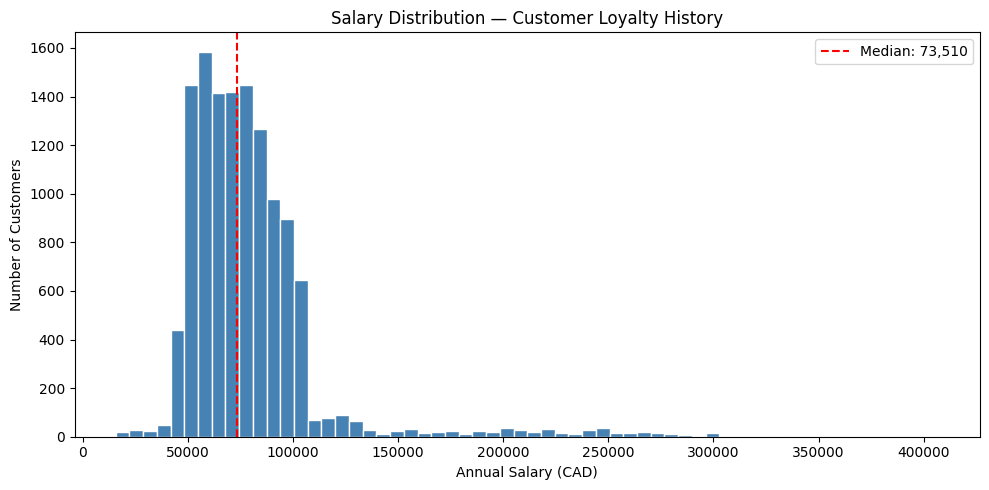

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_60144\1074579966.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clh[clh['Salary'].notna()], x='Education', y='Salary', order=edu_order, palette='Blues')


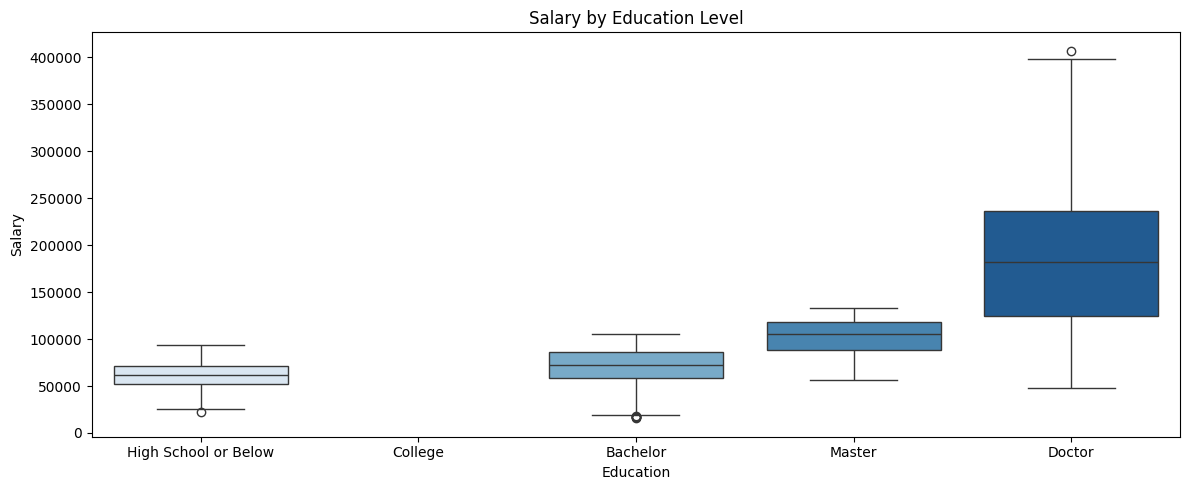

In [12]:
# Step 1: Check the high end — what does salary look like above 200k?
high_salary = clh[clh['Salary'] > 200000]
print(f"Customers with salary > 200k: {len(high_salary)}")
print(high_salary[['Education', 'Loyalty Card', 'Marital Status', 'Salary']].value_counts())

# Step 2: Plot salary distribution (after removing negatives)
plt.figure(figsize=(10, 5))
plt.hist(clh['Salary'].dropna(), bins=60, color='steelblue', edgecolor='white')
plt.axvline(clh['Salary'].median(), color='red', linestyle='--', label=f"Median: {clh['Salary'].median():,.0f}")
plt.title("Salary Distribution — Customer Loyalty History")
plt.xlabel("Annual Salary (CAD)")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

# Step 3: Box plot by education level to see if salary ordering makes sense
plt.figure(figsize=(12, 5))
edu_order = ['High School or Below', 'College', 'Bachelor', 'Master', 'Doctor']
sns.boxplot(data=clh[clh['Salary'].notna()], x='Education', y='Salary', order=edu_order, palette='Blues')
plt.title("Salary by Education Level")
plt.tight_layout()
plt.show()

missing salary analysis

In [13]:
clh.isnull().sum()

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4258
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

In [14]:
# ── SALARY: COMPLETE FIX (replaces all previous salary blocks) ─────────────

# 1. Confirm ALL missing salaries belong to College — should be only entry
print("\nEducation breakdown of missing salary records:")
print(clh[clh['Salary'].isnull()]['Education'].value_counts())

# 2. Missing by province (your original check — kept for report documentation)
print("\nMissing salaries by province:")
print(clh[clh['Salary'].isnull()]['Province'].value_counts())

# 3. Missing by Loyalty Card
print("\nMissing salaries by Loyalty Card:")
print(clh[clh['Salary'].isnull()]['Loyalty Card'].value_counts())


# 4. Drop leftover columns from the failed previous attempt
stale_cols = ['Salary_Group_Median', 'Salary_Imputed',
              'Salary_Was_Missing', 'Salary_Was_College_Missing']
clh.drop(columns=[c for c in stale_cols if c in clh.columns], inplace=True)

# 5. Group medians for non-College only (College has zero non-null rows — excluded)
group_medians = (
    clh[clh['Education'] != 'College']
    .groupby(['Education', 'Marital Status'])['Salary']
    .median()
    .reset_index()
    .rename(columns={'Salary': 'Salary_Group_Median'})
)
print("\nGroup medians for non-College groups:")
print(group_medians.to_string(index=False))

clh = clh.merge(group_medians, on=['Education', 'Marital Status'], how='left')

# 6. Build Salary_Imputed from scratch
clh['Salary_Imputed'] = clh['Salary'].copy()

# 7. Non-College groups: fill with their Education × Marital Status median
clh['Salary_Imputed'] = clh['Salary_Imputed'].fillna(clh['Salary_Group_Median'])

# 8. College fallback: median of already-imputed non-College salaries
#    (computed AFTER step 7 so non-College values are fully clean)
college_fallback = clh[clh['Education'] != 'College']['Salary_Imputed'].median()
clh['Salary_Imputed'] = clh['Salary_Imputed'].fillna(college_fallback)
print(f"\nCollege imputed with fallback: {college_fallback:,.0f}")

# 9. Flag columns — two separate flags for precise reporting
clh['Salary_Was_Missing']         = clh['Salary'].isnull().astype(int)
clh['Salary_Was_College_Missing'] = (
    (clh['Education'] == 'College') & clh['Salary'].isnull()
).astype(int)

# 10. Verification — these three numbers must match your expectations
print(f"\nNull Salary_Imputed remaining : {clh['Salary_Imputed'].isnull().sum()}")  # Must be 0
print(f"Total imputed records         : {clh['Salary_Was_Missing'].sum()}")        # ~4,238+
print(f"College-specific imputations  : {clh['Salary_Was_College_Missing'].sum()}") # 4,238

# 11. Sanity check — salary should increase with education level
edu_order = ['High School or Below', 'College', 'Bachelor', 'Master', 'Doctor']
print("\nMedian Salary_Imputed by Education (should increase left to right):")
print(clh.groupby('Education')['Salary_Imputed']
        .median()
        .reindex(edu_order)
        .apply(lambda x: f"{x:,.0f}"))


Education breakdown of missing salary records:
Education
College                 4238
Bachelor                  19
High School or Below       1
Name: count, dtype: int64

Missing salaries by province:
Province
Ontario                 1392
British Columbia        1140
Quebec                   830
Alberta                  244
Manitoba                 168
New Brunswick            146
Nova Scotia              111
Saskatchewan             107
Newfoundland              69
Yukon                     32
Prince Edward Island      19
Name: count, dtype: int64

Missing salaries by Loyalty Card:
Loyalty Card
Star      2120
Nova      1341
Aurora     797
Name: count, dtype: int64

Group medians for non-College groups:
           Education Marital Status  Salary_Group_Median
            Bachelor       Divorced              71195.0
            Bachelor        Married              72646.0
            Bachelor         Single              70347.5
              Doctor       Divorced             195145.0
 

In [15]:
clh.columns

Index(['Loyalty Number', 'Country', 'Province', 'City', 'Postal Code',
       'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card',
       'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month',
       'Cancellation Year', 'Cancellation Month', 'Salary_Group_Median',
       'Salary_Imputed', 'Salary_Was_Missing', 'Salary_Was_College_Missing'],
      dtype='str')

CLV INVESTIGATION

Total customers: 16737
Unique CLV values: 7984
Ratio (unique / total): 0.477
CLV
8564.77    13
3861.49    12
3873.65    12
3939.01    12
4250.28    12
4270.03    12
4282.95    12
4330.39    12
4334.06    12
4362.93    12
4376.36    12
4463.00    12
4669.23    12
5989.77    12
4770.55    12
2004.35    12
2393.92    12
4904.89    12
2725.36    12
5015.01    12
5181.62    12
5332.46    12
5380.90    12
5470.06    12
5504.14    12
5595.39    12
5639.94    12
5678.05    12
5926.73    12
6005.21    12
Name: count, dtype: int64

Customers sharing their CLV with at least one other person: 15457
Percentage: 92.4%

Demo groups where CLV has exactly 1 unique value: 5908 / 6024


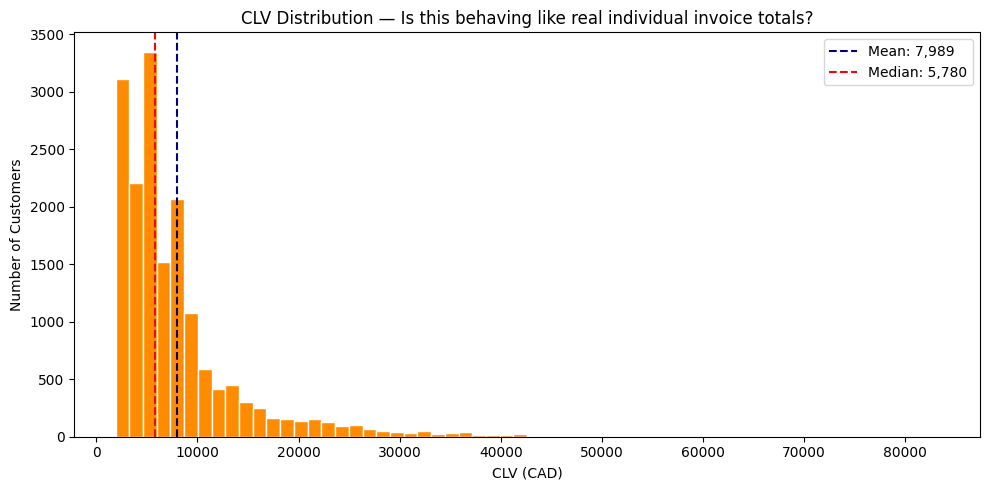


CLV by Loyalty Card Tier:
                      mean   median      min       max
Loyalty Card                                          
Aurora        10672.686325  8140.00  4936.89  73225.96
Nova           8045.615995  5799.06  2738.00  74228.52
Star           6741.761372  4786.89  1898.01  83325.38

Correlation between CLV and Salary: -0.0210


In [16]:
# Step 1: How many unique CLV values exist?
print(f"Total customers: {len(clh)}")
print(f"Unique CLV values: {clh['CLV'].nunique()}")
print(f"Ratio (unique / total): {clh['CLV'].nunique() / len(clh):.3f}")

# Step 2: Full frequency distribution — top 30 most common CLV values
clv_freq = clh['CLV'].value_counts().head(30)
print(clv_freq)
print(f"\nCustomers sharing their CLV with at least one other person: "
      f"{len(clh[clh.duplicated(subset=['CLV'], keep=False)])}")
print(f"Percentage: {len(clh[clh.duplicated(subset=['CLV'], keep=False)]) / len(clh) * 100:.1f}%")

# Step 3: Check if CLV is deterministically driven by demographics
# Build a composite demographic key and see if CLV is unique within it
clh['demo_key'] = (clh['Education'].astype(str) + '_' +
                   clh['Salary'].astype(str) + '_' +
                   clh['Marital Status'].astype(str))
clv_by_demo = clh.groupby('demo_key')['CLV'].nunique()
print(f"\nDemo groups where CLV has exactly 1 unique value: "
      f"{(clv_by_demo == 1).sum()} / {len(clv_by_demo)}")
# If this is near 100%, CLV is fully determined by demographics

# Step 4: CLV distribution plot
plt.figure(figsize=(10, 5))
plt.hist(clh['CLV'], bins=60, color='darkorange', edgecolor='white')
plt.axvline(clh['CLV'].mean(), color='navy', linestyle='--', label=f"Mean: {clh['CLV'].mean():,.0f}")
plt.axvline(clh['CLV'].median(), color='red', linestyle='--', label=f"Median: {clh['CLV'].median():,.0f}")
plt.title("CLV Distribution — Is this behaving like real individual invoice totals?")
plt.xlabel("CLV (CAD)")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.savefig("clv_distribution.png", dpi=150)
plt.show()

# Step 5: CLV by loyalty card tier (should increase Aurora > Nova > Star)
clv_by_tier = clh.groupby('Loyalty Card')['CLV'].agg(['mean', 'median', 'min', 'max'])
print("\nCLV by Loyalty Card Tier:")
print(clv_by_tier)

# Step 6: Correlation between CLV and Salary
print(f"\nCorrelation between CLV and Salary: {clh[['CLV', 'Salary']].corr().iloc[0,1]:.4f}")

In [17]:
# What actually drives CLV differences?
print("CLV correlation with key variables:")
clh['Loyalty_Card_Encoded'] = clh['Loyalty Card'].map({'Star': 1, 'Nova': 2, 'Aurora': 3})
clh['Education_Encoded'] = clh['Education'].map({
    'High School or Below': 1, 'College': 2,
    'Bachelor': 3, 'Master': 4, 'Doctor': 5
})

# Calculate Tenure_Months within this cell
REFERENCE_YEAR = 2018
REFERENCE_MONTH = 12

clh['Tenure_Months'] = (
    (REFERENCE_YEAR - clh['Enrollment Year']) * 12 +
    (REFERENCE_MONTH - clh['Enrollment Month'])
)

# For cancelled members, calculate tenure at cancellation instead
cancelled_mask = clh['Cancellation Year'].notna()
clh.loc[cancelled_mask, 'Tenure_Months'] = (
    (clh.loc[cancelled_mask, 'Cancellation Year'] - clh.loc[cancelled_mask, 'Enrollment Year']) * 12 +
    (clh.loc[cancelled_mask, 'Cancellation Month'] - clh.loc[cancelled_mask, 'Enrollment Month'])
)

corr_vars = clh[['CLV', 'Salary_Imputed', 'Loyalty_Card_Encoded',
                  'Education_Encoded', 'Tenure_Months']].corr()['CLV'].sort_values(ascending=False)
print(corr_vars)

CLV correlation with key variables:
CLV                     1.000000
Loyalty_Card_Encoded    0.210904
Education_Encoded       0.018135
Tenure_Months          -0.004065
Salary_Imputed         -0.015530
Name: CLV, dtype: float64


In [18]:
clh[clh['CLV'] == 10963.96]

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,...,Cancellation Year,Cancellation Month,Salary_Group_Median,Salary_Imputed,Salary_Was_Missing,Salary_Was_College_Missing,demo_key,Loyalty_Card_Encoded,Education_Encoded,Tenure_Months
3191,682356,Canada,Ontario,Toronto,P1J 8T7,Male,Bachelor,72656.0,Divorced,Aurora,...,NaN,NaN,71195.0,72656.0,0,0,Bachelor_72656.0_Divorced,3,3,55
3192,861470,Canada,New Brunswick,Moncton,E1A 2A7,Male,Bachelor,72656.0,Divorced,Aurora,...,NaN,NaN,71195.0,72656.0,0,0,Bachelor_72656.0_Divorced,3,3,27
3193,904736,Canada,Alberta,Edmonton,T3G 6Y6,Female,Bachelor,72656.0,Divorced,Aurora,...,NaN,NaN,71195.0,72656.0,0,0,Bachelor_72656.0_Divorced,3,3,27
8815,144977,Canada,British Columbia,Vancouver,V1E 4R6,Female,Bachelor,72656.0,Divorced,Nova,...,NaN,NaN,71195.0,72656.0,0,0,Bachelor_72656.0_Divorced,2,3,74
8816,300836,Canada,Ontario,Toronto,P1J 8T7,Male,Bachelor,72656.0,Divorced,Nova,...,NaN,NaN,71195.0,72656.0,0,0,Bachelor_72656.0_Divorced,2,3,40
8817,408378,Canada,Quebec,Tremblant,H5Y 2S9,Female,Bachelor,72656.0,Divorced,Nova,...,NaN,NaN,71195.0,72656.0,0,0,Bachelor_72656.0_Divorced,2,3,5
8818,575089,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,72656.0,Divorced,Nova,...,NaN,NaN,71195.0,72656.0,0,0,Bachelor_72656.0_Divorced,2,3,0
8819,945974,Canada,Ontario,Toronto,M2M 7K8,Male,Bachelor,72656.0,Divorced,Nova,...,NaN,NaN,71195.0,72656.0,0,0,Bachelor_72656.0_Divorced,2,3,23
15714,213545,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,72656.0,Divorced,Star,...,NaN,NaN,71195.0,72656.0,0,0,Bachelor_72656.0_Divorced,1,3,5
15715,225205,Canada,British Columbia,Vancouver,V5R 1W3,Female,Bachelor,72656.0,Divorced,Star,...,NaN,NaN,71195.0,72656.0,0,0,Bachelor_72656.0_Divorced,1,3,7


In [19]:
# Step 1: Size and basic profile of promotion cohort
promo = clh[clh['Enrollment Type'] == '2018 Promotion']
standard = clh[clh['Enrollment Type'] == 'Standard']
print(f"2018 Promotion members: {len(promo)} ({len(promo)/len(clh)*100:.1f}%)")
print(f"Standard members: {len(standard)}")

# Step 2: Profile comparison — are promotion members structurally different?
comparison = pd.DataFrame({
    'Standard': standard[['Salary_Imputed', 'CLV']].mean(),
    '2018 Promotion': promo[['Salary_Imputed', 'CLV']].mean()
})
print("\nMean Salary and CLV by Enrollment Type:")
print(comparison)

# Step 3: Loyalty Card tier breakdown by enrollment type
print("\nLoyalty Card distribution for Standard vs Promotion:")
print(pd.crosstab(clh['Enrollment Type'], clh['Loyalty Card'], normalize='index') * 100)

# Step 4: Did promotion members cancel more? (check cancellation rate)
for etype in ['Standard', '2018 Promotion']:
    subset = clh[clh['Enrollment Type'] == etype]
    cancel_rate = subset['Cancellation Year'].notna().sum() / len(subset) * 100
    print(f"{etype} cancellation rate: {cancel_rate:.1f}%")

2018 Promotion members: 971 (5.8%)
Standard members: 15766

Mean Salary and CLV by Enrollment Type:
                    Standard  2018 Promotion
Salary_Imputed  78128.380502    74323.011843
CLV              7985.348187     8046.510618

Loyalty Card distribution for Standard vs Promotion:
Loyalty Card        Aurora       Nova       Star
Enrollment Type                                 
2018 Promotion   21.421215  33.985582  44.593203
Standard         20.430039  33.876697  45.693264
Standard cancellation rate: 12.4%
2018 Promotion cancellation rate: 11.8%


Cancellation Analysis

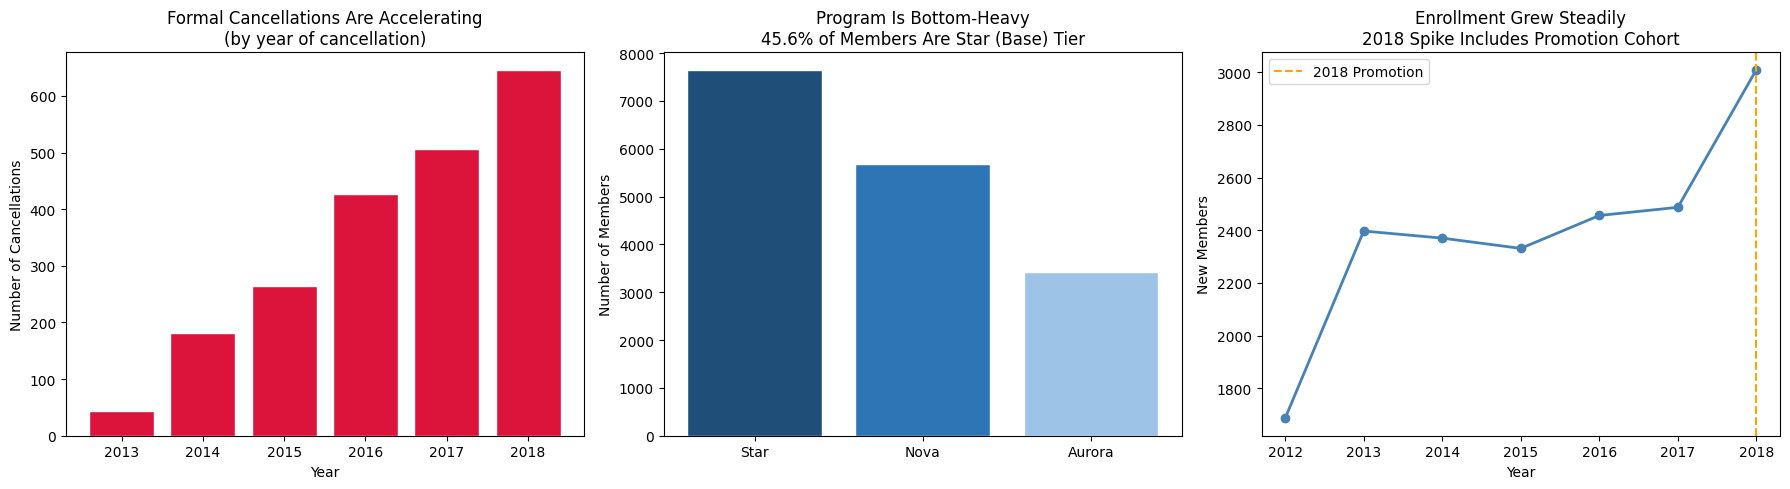

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Cancellations by year (is churn accelerating?)
cancel_by_year = clh[clh['Cancellation Year'].notna()]['Cancellation Year'].value_counts().sort_index()
axes[0].bar(cancel_by_year.index.astype(int), cancel_by_year.values, color='crimson', edgecolor='white')
axes[0].set_title("Formal Cancellations Are Accelerating\n(by year of cancellation)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Cancellations")

# Chart 2: Loyalty tier distribution
tier_colors = ['#1f4e79', '#2e75b6', '#9dc3e6']
axes[1].bar(['Star', 'Nova', 'Aurora'],
             [7637, 5671, 3429],
             color=tier_colors, edgecolor='white')
axes[1].set_title("Program Is Bottom-Heavy\n45.6% of Members Are Star (Base) Tier")
axes[1].set_ylabel("Number of Members")

# Chart 3: Enrollment growth by year
enroll_by_year = clh.groupby('Enrollment Year').size()
axes[2].plot(enroll_by_year.index, enroll_by_year.values,
             marker='o', color='steelblue', linewidth=2)
axes[2].axvline(x=2018, color='orange', linestyle='--', label='2018 Promotion')
axes[2].set_title("Enrollment Grew Steadily\n2018 Spike Includes Promotion Cohort")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("New Members")
axes[2].legend()

plt.tight_layout()
plt.savefig("clh_key_charts.png", dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Step 1: Overall cancellation rate
cancelled = clh[clh['Cancellation Year'].notna()]
print(f"Formally cancelled members: {len(cancelled)} ({len(cancelled)/len(clh)*100:.1f}%)")
print(f"Still active (no cancellation): {len(clh) - len(cancelled)} ({(len(clh)-len(cancelled))/len(clh)*100:.1f}%)")

# Step 2: Distribution of cancellation by year
print("\nCancellations by Year:")
print(cancelled['Cancellation Year'].value_counts().sort_index())

# Step 3: CRITICAL — Check for impossible records (cancelled before enrolled)
clh['Enrollment_Date'] = clh['Enrollment Year'] * 100 + clh['Enrollment Month']
clh['Cancellation_Date'] = clh['Cancellation Year'] * 100 + clh['Cancellation Month']
impossible = clh[clh['Cancellation_Date'] < clh['Enrollment_Date']]
print(f"\nImpossible records (cancelled before enrolled): {len(impossible)}")

# Step 4: Calculate tenure at cancellation (in months)
cancelled_copy = cancelled.copy()
cancelled_copy['Tenure_Months'] = (
    (cancelled_copy['Cancellation Year'] - cancelled_copy['Enrollment Year']) * 12 +
    (cancelled_copy['Cancellation Month'] - cancelled_copy['Enrollment Month'])
)
print("\nTenure at cancellation (months) — statistics:")
print(cancelled_copy['Tenure_Months'].describe())

# Step 5: Who cancels more — which loyalty tier, which province?
print("\nCancellation rate by Loyalty Card tier:")
tier_cancel = clh.groupby('Loyalty Card')['Cancellation Year'].apply(
    lambda x: x.notna().sum() / len(x) * 100
).round(1)
print(tier_cancel)

print("\nCancellation rate by Province (top 8 provinces):")
prov_cancel = clh.groupby('Province')['Cancellation Year'].apply(
    lambda x: x.notna().sum() / len(x) * 100
).sort_values(ascending=False)
print(prov_cancel)

Formally cancelled members: 2067 (12.3%)
Still active (no cancellation): 14670 (87.7%)

Cancellations by Year:
Cancellation Year
2013.0     43
2014.0    181
2015.0    265
2016.0    427
2017.0    506
2018.0    645
Name: count, dtype: int64

Impossible records (cancelled before enrolled): 0

Tenure at cancellation (months) — statistics:
count    2067.000000
mean       15.882438
std        14.443776
min         0.000000
25%         8.000000
50%         8.000000
75%        20.000000
max        71.000000
Name: Tenure_Months, dtype: float64

Cancellation rate by Loyalty Card tier:
Loyalty Card
Aurora    13.1
Nova      12.6
Star      11.8
Name: Cancellation Year, dtype: float64

Cancellation rate by Province (top 8 provinces):
Province
Prince Edward Island    16.666667
Manitoba                15.197568
Newfoundland            14.728682
Alberta                 12.590299
Quebec                  12.515152
Ontario                 12.472243
Saskatchewan            12.224939
British Columbia       

In [22]:
# Separate early churners (< 12 months) from long-term churners
cancelled_members = clh[clh['Cancellation Year'].notna()].copy()
early_churners = cancelled_members[cancelled_members['Tenure_Months'] < 12]
late_churners = cancelled_members[cancelled_members['Tenure_Months'] >= 12]

print(f"Early churners (< 12 months): {len(early_churners)} ({len(early_churners)/len(cancelled_members)*100:.1f}%)")
print(f"Late churners (12+ months): {len(late_churners)} ({len(late_churners)/len(cancelled_members)*100:.1f}%)")

# Profile early vs late churners
print("\nEarly churner loyalty card distribution:")
print(early_churners['Loyalty Card'].value_counts(normalize=True).mul(100).round(1))
print("\nLate churner loyalty card distribution:")
print(late_churners['Loyalty Card'].value_counts(normalize=True).mul(100).round(1))

Early churners (< 12 months): 1347 (65.2%)
Late churners (12+ months): 720 (34.8%)

Early churner loyalty card distribution:
Loyalty Card
Star      43.1
Nova      34.4
Aurora    22.6
Name: proportion, dtype: float64

Late churner loyalty card distribution:
Loyalty Card
Star      44.6
Nova      35.3
Aurora    20.1
Name: proportion, dtype: float64


In [23]:
# Step 1: Loyalty card distribution
print("Loyalty Card Distribution:")
tier_dist = clh['Loyalty Card'].value_counts()
tier_pct = clh['Loyalty Card'].value_counts(normalize=True) * 100
print(pd.concat([tier_dist, tier_pct.round(1)], axis=1, keys=['Count', 'Percent']))

# Step 2: Education distribution — also check ordinal ordering makes sense
print("\nEducation Distribution:")
edu_order = ['High School or Below', 'College', 'Bachelor', 'Master', 'Doctor']
edu_dist = clh['Education'].value_counts()[edu_order]
print(edu_dist)

# Step 3: Loyalty Card by Education cross-tab (very insightful)
# Higher education → higher tier? This validates your segmentation logic
tier_by_edu = pd.crosstab(clh['Education'], clh['Loyalty Card'], normalize='index') * 100
tier_by_edu = tier_by_edu[['Star', 'Nova', 'Aurora']]
print("\n% of each education level in each loyalty tier:")
print(tier_by_edu.round(1))

# Step 4: Enrollment Type breakdown
print("\nEnrollment Type Distribution:")
print(clh['Enrollment Type'].value_counts())
print(clh['Enrollment Type'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))

# Step 5: Enrollment year trend — are memberships growing or shrinking?
print("\nNew Enrollments by Year:")
enrollment_trend = clh['Enrollment Year'].value_counts().sort_index()
print(enrollment_trend)

Loyalty Card Distribution:
              Count  Percent
Loyalty Card                
Star           7637     45.6
Nova           5671     33.9
Aurora         3429     20.5

Education Distribution:
Education
High School or Below      782
College                  4238
Bachelor                10475
Master                    508
Doctor                    734
Name: count, dtype: int64

% of each education level in each loyalty tier:
Loyalty Card          Star  Nova  Aurora
Education                               
Bachelor              42.9  35.2    21.8
College               49.8  31.4    18.7
Doctor                47.7  33.9    18.4
High School or Below  51.0  31.6    17.4
Master                54.7  29.7    15.6

Enrollment Type Distribution:
Enrollment Type
Standard          15766
2018 Promotion      971
Name: count, dtype: int64
Enrollment Type
Standard          94.2%
2018 Promotion     5.8%
Name: proportion, dtype: str

New Enrollments by Year:
Enrollment Year
2012    1686
2013    2397

In [24]:
# Chi-square test to confirm education and tier are independent
from scipy.stats import chi2_contingency
contingency = pd.crosstab(clh['Education'], clh['Loyalty Card'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"Chi-square test: Education vs Loyalty Card")
print(f"p-value: {p_value:.4f}")
# If p > 0.05, education and tier are statistically independent
# If p < 0.05, there IS a relationship but it may be weak
print(f"\nConclusion: {'Statistically related' if p_value < 0.05 else 'Statistically independent'}")

Chi-square test: Education vs Loyalty Card
p-value: 0.0000

Conclusion: Statistically related


In [25]:
# Step 1: Calculate how long each member has been enrolled (as of end of dataset = Dec 2018)
# This becomes an important feature — longer tenure members churn differently
REFERENCE_YEAR = 2018
REFERENCE_MONTH = 12

clh['Tenure_Months'] = (
    (REFERENCE_YEAR - clh['Enrollment Year']) * 12 +
    (REFERENCE_MONTH - clh['Enrollment Month'])
)

# Step 2: For cancelled members, calculate tenure at cancellation instead
cancelled_mask = clh['Cancellation Year'].notna()
clh.loc[cancelled_mask, 'Tenure_Months'] = (
    (clh.loc[cancelled_mask, 'Cancellation Year'] - clh.loc[cancelled_mask, 'Enrollment Year']) * 12 +
    (clh.loc[cancelled_mask, 'Cancellation Month'] - clh.loc[cancelled_mask, 'Enrollment Month'])
)

print("Tenure distribution (months):")
print(clh['Tenure_Months'].describe())

# Step 3: Check for negative tenure (impossible — means data error)
print(f"\nCustomers with negative tenure: {(clh['Tenure_Months'] < 0).sum()}")

Tenure distribution (months):
count    16737.000000
mean        35.451933
std         24.384892
min          0.000000
25%         11.000000
50%         33.000000
75%         57.000000
max         80.000000
Name: Tenure_Months, dtype: float64

Customers with negative tenure: 0


In [26]:
# Prove CLV doesn't reflect actual behavior by checking enrolled-same-year vs different-year customers
# If CLV is truly cumulative invoices, a 2012 enrollee should ALWAYS have higher CLV than a 2018 enrollee
# (assuming similar behavior) — test if this holds

clv_by_enrollment = clh.groupby('Enrollment Year')['CLV'].agg(['mean', 'median'])
print("Mean and Median CLV by Enrollment Year:")
print(clv_by_enrollment)
# If CLV doesn't grow with enrollment year, it's not a cumulative behavioral metric

# Also: check if Aurora card holders (highest tier = most flights) have proportionally higher CLV
print("\nCLV by Loyalty Card Tier:")
print(clh.groupby('Loyalty Card')['CLV'].agg(['mean', 'median', 'count']))

Mean and Median CLV by Enrollment Year:
                        mean   median
Enrollment Year                      
2012             7998.542100  5682.52
2013             8045.484268  5801.13
2014             7850.489899  5774.52
2015             8177.793411  5757.44
2016             8058.057993  5882.70
2017             7776.879976  5704.98
2018             8019.868811  5793.62

CLV by Loyalty Card Tier:
                      mean   median  count
Loyalty Card                              
Aurora        10672.686325  8140.00   3429
Nova           8045.615995  5799.06   5671
Star           6741.761372  4786.89   7637


In [ ]:
# Drop helper columns that were only used for analysis
clh_clean = clh.drop(columns=['Salary_Group_Median', 'demo_key',
                                'Enrollment_Date', 'Cancellation_Date',
                                'Loyalty_Card_Encoded', 'Education_Encoded'],
                      errors='ignore')

clh_clean.to_csv('data/processed/clh_cleaned.csv', index=False)

print("Final CLH shape:", clh_clean.shape)
print("\nFinal null counts (only these should remain):")
print(clh_clean.isnull().sum()[clh_clean.isnull().sum() > 0])
# Only Cancellation Year/Month should show nulls (= active members)

Final CLH shape: (16737, 20)

Final null counts (only these should remain):
Salary                 4258
Cancellation Year     14670
Cancellation Month    14670
dtype: int64


## CFA ANALYSIS

In [ ]:
cfa=pd.read_csv('data/raw/Customer Flight Activity.csv')

In [30]:
print(cfa.head())
print(cfa.shape)

   Loyalty Number  Year  Month  Total Flights  Distance  Points Accumulated  \
0          100590  2018      6             12     15276             22914.0   
1          100590  2018      7             12      9168             13752.0   
2          100590  2018      5              4      6504              9756.0   
3          100590  2018     10              0         0                 0.0   
4          100590  2018      2              0         0                 0.0   

   Points Redeemed  Dollar Cost Points Redeemed  
0                0                            0  
1                0                            0  
2                0                            0  
3              512                           92  
4                0                            0  
(392936, 8)


In [31]:
cfa.info()

<class 'pandas.DataFrame'>
RangeIndex: 392936 entries, 0 to 392935
Data columns (total 8 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               392936 non-null  int64  
 1   Year                         392936 non-null  int64  
 2   Month                        392936 non-null  int64  
 3   Total Flights                392936 non-null  int64  
 4   Distance                     392936 non-null  int64  
 5   Points Accumulated           392936 non-null  float64
 6   Points Redeemed              392936 non-null  int64  
 7   Dollar Cost Points Redeemed  392936 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 24.0 MB


In [32]:
cfa.describe()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
count,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000
mean,550527.519034,2017.513661,6.513661,1.294888,1941.440201,2027.172345,31.304263,5.635661
std,258604.580187,0.499814,3.445428,1.962675,3239.975889,3872.139841,126.653775,22.801167
min,100018.000000,2017.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,327688.000000,2017.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,551833.000000,2018.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,772194.000000,2018.000000,10.000000,2.000000,3018.000000,3039.000000,0.000000,0.000000
max,999986.000000,2018.000000,12.000000,28.000000,67284.000000,100926.000000,876.000000,158.000000


In [33]:
print(f"\nYears covered: {sorted(cfa['Year'].unique())}")
print(f"Months covered: {sorted(cfa['Month'].unique())}")
print(f"Unique customers: {cfa['Loyalty Number'].nunique()}")


Years covered: [np.int64(2017), np.int64(2018)]
Months covered: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Unique customers: 16737


In [34]:
print("Full year range in CFA:")
print(sorted(cfa['Year'].unique()))
print(f"\nTotal months of data per customer (avg): {len(cfa)/cfa['Loyalty Number'].nunique():.1f}")

Full year range in CFA:
[np.int64(2017), np.int64(2018)]

Total months of data per customer (avg): 23.5


In [35]:
# ── PANEL COMPLETENESS ──────────────────────────────────────────────────────
# Every customer should have exactly 12 rows per year
rows_per_cy = cfa.groupby(['Loyalty Number', 'Year']).size().value_counts().sort_index()
print("Row count distribution per customer-year (12 = complete):")
print(rows_per_cy)

# Customers missing from certain years entirely
customers_per_year = cfa.groupby('Year')['Loyalty Number'].nunique()
print(f"\nUnique customers per year:")
print(customers_per_year)

Row count distribution per customer-year (12 = complete):
11      966
12    31216
22        5
24      314
36        2
Name: count, dtype: int64

Unique customers per year:
Year
2017    15766
2018    16737
Name: Loyalty Number, dtype: int64


In [36]:
# Identify duplicates
dupes = cfa[cfa.duplicated(subset=['Loyalty Number', 'Year', 'Month'], keep=False)]
print(f"Duplicate customer-year-month rows: {len(dupes)}")
print(f"Affected customers: {dupes['Loyalty Number'].nunique()}")
print("\nExample — same customer, same month, two rows:")
print(dupes.sort_values(['Loyalty Number', 'Year', 'Month']).head(6).to_string(index=False))

Duplicate customer-year-month rows: 7718
Affected customers: 163

Example — same customer, same month, two rows:
 Loyalty Number  Year  Month  Total Flights  Distance  Points Accumulated  Points Redeemed  Dollar Cost Points Redeemed
         101902  2017      1              0         0                 0.0                0                            0
         101902  2017      1              0         0                 0.0                0                            0
         101902  2017      2              0         0                 0.0                0                            0
         101902  2017      2              0         0                 0.0                0                            0
         101902  2017      3              0         0                 0.0                0                            0
         101902  2017      3              0         0                 0.0                0                            0


In [37]:
# Document the 163 duplicate-affected customers — are they concentrated anywhere?
affected = [163]  # from your output
dup_customers = (cfa.groupby(['Loyalty Number','Year'])
                    .filter(lambda x: len(x) > 12)['Loyalty Number']
                    .unique())

# Cross-check with CLH
dup_profile = clh[clh['Loyalty Number'].isin(dup_customers)][
    ['Loyalty Card','Enrollment Type','Province']
].describe(include='all')
print("Profile of 163 duplicate-affected customers:")
print(clh[clh['Loyalty Number'].isin(dup_customers)]['Loyalty Card'].value_counts())
print(clh[clh['Loyalty Number'].isin(dup_customers)]['Enrollment Type'].value_counts())

Profile of 163 duplicate-affected customers:
Loyalty Card
Aurora    64
Nova      60
Star      39
Name: count, dtype: int64
Enrollment Type
Standard          158
2018 Promotion      5
Name: count, dtype: int64


In [38]:
# Fix: keep the row with more activity (higher flights), then sum if genuinely different
# First check if duplicates are identical or have different values
dup_check = (cfa.groupby(['Loyalty Number', 'Year', 'Month'])
               .filter(lambda x: len(x) > 1)
               .groupby(['Loyalty Number', 'Year', 'Month'])
               [['Total Flights', 'Distance', 'Points Accumulated']]
               .std()
               .fillna(0))
print("Are duplicate rows identical (std=0) or different (std>0)?")
print((dup_check == 0).all(axis=1).value_counts())
# True = identical copies → drop one. False = different values → needs aggregation

Are duplicate rows identical (std=0) or different (std>0)?
False    1932
True     1915
Name: count, dtype: int64


In [39]:
# Deduplicate — aggregate by summing activity columns, keeping first for identifiers
cfa_clean = (cfa.groupby(['Loyalty Number', 'Year', 'Month'], as_index=False)
               .agg({
                   'Total Flights'               : 'sum',
                   'Distance'                    : 'sum',
                   'Points Accumulated'          : 'sum',
                   'Points Redeemed'             : 'sum',
                   'Dollar Cost Points Redeemed' : 'sum'
               }))

print(f"Rows before dedup: {len(cfa):,}")
print(f"Rows after dedup : {len(cfa_clean):,}")
print(f"Rows removed     : {len(cfa) - len(cfa_clean):,}")
cfa = cfa_clean.copy()

Rows before dedup: 392,936
Rows after dedup : 389,065
Rows removed     : 3,871


In [40]:
# Find which month is missing for incomplete customer-years
incomplete = (cfa.groupby(['Loyalty Number', 'Year'])
                .filter(lambda x: len(x) < 12))
all_months = set(range(1, 13))
missing_months = (incomplete.groupby(['Loyalty Number', 'Year'])['Month']
                             .apply(lambda x: list(all_months - set(x))))
print("Which months are most commonly missing:")
print(missing_months.explode().value_counts().sort_index())

Which months are most commonly missing:
Month
1    971
Name: count, dtype: int64


In [41]:
# Fix: fill missing months with zero activity
from itertools import product
all_cy = pd.DataFrame(
    [(ln, yr, mo)
     for ln in cfa['Loyalty Number'].unique()
     for yr in cfa['Year'].unique()
     for mo in range(1, 13)],
    columns=['Loyalty Number', 'Year', 'Month']
)
cfa = all_cy.merge(cfa, on=['Loyalty Number', 'Year', 'Month'], how='left').fillna(0)
cfa[['Year', 'Month']] = cfa[['Year', 'Month']].astype(int)

print(f"CFA after filling missing months: {cfa.shape}")
print(f"All customer-years now have 12 rows: "
      f"{(cfa.groupby(['Loyalty Number','Year']).size() == 12).all()}")

CFA after filling missing months: (401688, 8)
All customer-years now have 12 rows: True


In [43]:
# ── ANOMALY CHECKS ──────────────────────────────────────────────────────────
for col in ['Total Flights', 'Distance', 'Points Accumulated',
            'Points Redeemed', 'Dollar Cost Points Redeemed']:
    neg = (cfa[col] < 0).sum()
    if neg > 0:
        print(f"Negative values in {col}: {neg}")

print(f"Flights=0 but Distance>0 : {((cfa['Total Flights']==0) & (cfa['Distance']>0)).sum()}")
print(f"Flights>0 but Distance=0 : {((cfa['Total Flights']>0) & (cfa['Distance']==0)).sum()}")
print(f"Points earned=0 but Flights>0: {((cfa['Points Accumulated']==0) & (cfa['Total Flights']>0)).sum()}")

Flights=0 but Distance>0 : 0
Flights>0 but Distance=0 : 0
Points earned=0 but Flights>0: 0


In [44]:
# ── REDEMPTION WITHOUT FLIGHT ────────────────────────────────────────────────
redeem_no_fly = cfa[(cfa['Points Redeemed'] > 0) & (cfa['Total Flights'] == 0)]
total_redeem_months = (cfa['Points Redeemed'] > 0).sum()

print(f"Redemption months with zero flights : {len(redeem_no_fly):,}")
print(f"As % of all redemption activity     : {len(redeem_no_fly)/total_redeem_months*100:.1f}%")
print(f"Total dollar value of these redemptions: ${redeem_no_fly['Dollar Cost Points Redeemed'].sum():,.0f}")

Redemption months with zero flights : 2,918
As % of all redemption activity     : 12.2%
Total dollar value of these redemptions: $259,131


In [45]:
# ── ZERO ACTIVITY BASELINE ──────────────────────────────────────────────────
total_rows = len(cfa)
zero_flights = (cfa['Total Flights'] == 0).sum()
zero_all = ((cfa['Total Flights'] == 0) & (cfa['Points Redeemed'] == 0) &
            (cfa['Points Accumulated'] == 0)).sum()

print(f"Total customer-months          : {total_rows:,}")
print(f"Zero-flight months             : {zero_flights:,}  ({zero_flights/total_rows*100:.1f}%)")
print(f"Completely inactive months     : {zero_all:,}  ({zero_all/total_rows*100:.1f}%)")

Total customer-months          : 401,688
Zero-flight months             : 223,715  (55.7%)
Completely inactive months     : 220,797  (55.0%)


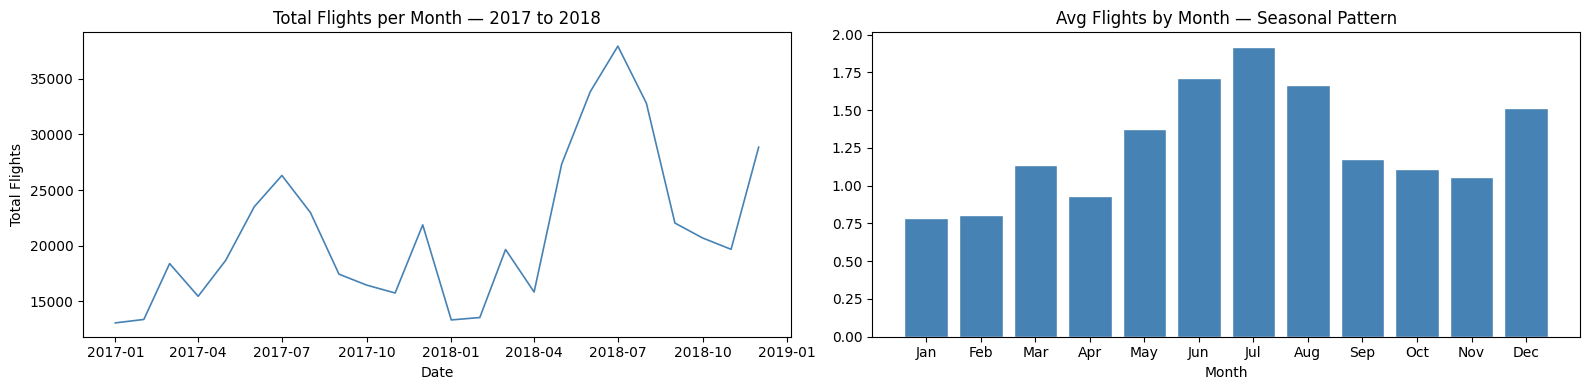

In [46]:
# ── MONTHLY ACTIVITY TREND 2017–2018 ────────────────────────────────────────
monthly = cfa.groupby(['Year', 'Month'])['Total Flights'].sum().reset_index()
monthly['Date'] = pd.to_datetime(dict(year=monthly['Year'],
                                      month=monthly['Month'], day=1))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(monthly['Date'], monthly['Total Flights'],
             color='steelblue', linewidth=1.2)
axes[0].set_title("Total Flights per Month — 2017 to 2018")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Total Flights")

seasonal = cfa.groupby('Month')['Total Flights'].mean()
axes[1].bar(seasonal.index, seasonal.values,
            color='steelblue', edgecolor='white')
axes[1].set_title("Avg Flights by Month — Seasonal Pattern")
axes[1].set_xlabel("Month")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.savefig("cfa_activity_trend.png", dpi=150)
plt.show()

In [47]:
# ── PER-CUSTOMER LIFETIME SUMMARY ───────────────────────────────────────────
customer_summary = cfa.groupby('Loyalty Number').agg(
    Total_Flights        = ('Total Flights',    'sum'),
    Total_Distance       = ('Distance',         'sum'),
    Points_Earned        = ('Points Accumulated','sum'),
    Points_Redeemed      = ('Points Redeemed',  'sum'),
    Dollar_Redeemed      = ('Dollar Cost Points Redeemed', 'sum'),
    Active_Months        = ('Total Flights',    lambda x: (x > 0).sum()),
    First_Active_Year    = ('Year',             'min'),
    Last_Active_Year     = ('Year',             'max')
).reset_index()

print(customer_summary.describe().round(1))
print(f"\nCustomers who never flew        : {(customer_summary['Total_Flights']==0).sum()}")
print(f"Customers who never redeemed    : {(customer_summary['Points_Redeemed']==0).sum()}")
print(f"Customers active in only 1 month: {(customer_summary['Active_Months']==1).sum()}")

       Loyalty Number  Total_Flights  Total_Distance  Points_Earned  \
count         16737.0        16737.0         16737.0        16737.0   
mean         549735.9           30.4         45579.4        47592.1   
std          258912.1           16.9         26092.3        30391.9   
min          100018.0            0.0             0.0            0.0   
25%          326603.0           20.0         28495.0        28718.0   
50%          550434.0           34.0         49445.0        49885.0   
75%          772019.0           42.0         62911.0        63812.0   
max          999986.0          106.0        178858.0       268287.0   

       Points_Redeemed  Dollar_Redeemed  Active_Months  First_Active_Year  \
count          16737.0          16737.0        16737.0            16737.0   
mean             734.9            132.3           10.6             2017.0   
std              716.6            129.0            5.7                0.0   
min                0.0              0.0            0

Redemption rate distribution (0=never redeemed, 1=redeemed all earned):
count    16737.000
mean         0.016
std          0.025
min          0.000
25%          0.000
50%          0.012
75%          0.023
max          1.000
Name: Redemption_Rate, dtype: float64

Never redeemed (rate=0)  : 5,259  (31.4%)
Rate > 50%               : 6


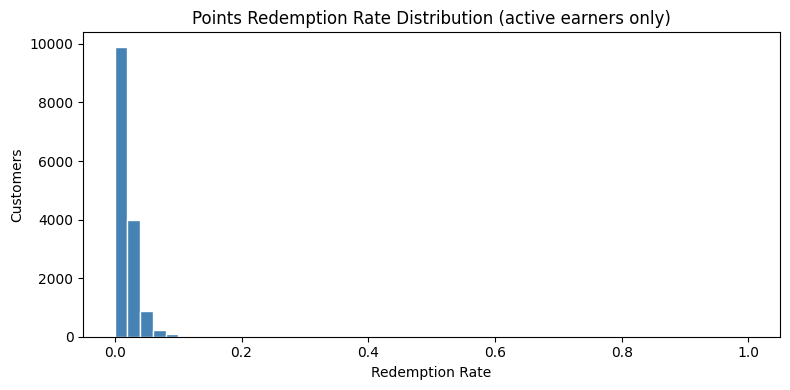

In [48]:
# ── POINTS REDEMPTION RATE PER CUSTOMER ─────────────────────────────────────
customer_summary['Redemption_Rate'] = (
    customer_summary['Points_Redeemed'] /
    customer_summary['Points_Earned'].replace(0, np.nan)
).fillna(0).clip(upper=1)

print("Redemption rate distribution (0=never redeemed, 1=redeemed all earned):")
print(customer_summary['Redemption_Rate'].describe().round(3))
print(f"\nNever redeemed (rate=0)  : {(customer_summary['Redemption_Rate']==0).sum():,}  "
      f"({(customer_summary['Redemption_Rate']==0).mean()*100:.1f}%)")
print(f"Rate > 50%               : {(customer_summary['Redemption_Rate']>0.5).sum():,}")

plt.figure(figsize=(8, 4))
plt.hist(customer_summary['Redemption_Rate'][customer_summary['Points_Earned']>0],
         bins=50, color='steelblue', edgecolor='white')
plt.title("Points Redemption Rate Distribution (active earners only)")
plt.xlabel("Redemption Rate")
plt.ylabel("Customers")
plt.tight_layout()
plt.savefig("cfa_redemption_rate.png", dpi=150)
plt.show()

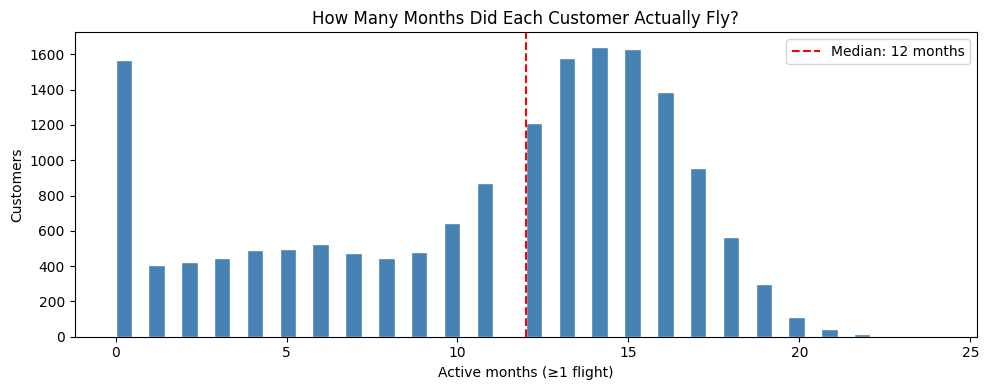

In [49]:
# ── ACTIVE MONTHS DISTRIBUTION ───────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(customer_summary['Active_Months'], bins=50,
         color='steelblue', edgecolor='white')
plt.axvline(customer_summary['Active_Months'].median(),
            color='red', linestyle='--',
            label=f"Median: {customer_summary['Active_Months'].median():.0f} months")
plt.title("How Many Months Did Each Customer Actually Fly?")
plt.xlabel("Active months (≥1 flight)")
plt.ylabel("Customers")
plt.legend()
plt.tight_layout()
plt.savefig("cfa_active_months.png", dpi=150)
plt.show()

In [50]:
# ── FLIGHT OUTLIER CHECK ─────────────────────────────────────────────────────
print("Percentile breakdown — flights per active month:")
print(cfa[cfa['Total Flights']>0]['Total Flights']
      .describe(percentiles=[.5,.75,.90,.95,.99]).round(1))

print("\nTop 10 single-month flight counts:")
print(cfa.nlargest(10, 'Total Flights')
        [['Loyalty Number','Year','Month','Total Flights','Distance']]
        .to_string(index=False))

Percentile breakdown — flights per active month:
count    177973.0
mean          2.9
std           2.0
min           1.0
50%           3.0
75%           4.0
90%           5.0
95%           6.0
99%           9.0
max          32.0
Name: Total Flights, dtype: float64

Top 10 single-month flight counts:
 Loyalty Number  Year  Month  Total Flights  Distance
         732304  2018      6           32.0   44952.0
         732304  2018      8           32.0   47360.0
         110065  2018      7           28.0   65184.0
         166175  2018      7           28.0   19432.0
         214095  2018      7           28.0   56364.0
         335246  2018      7           28.0   22680.0
         364710  2018      7           28.0   21756.0
         459164  2018      7           28.0   41160.0
         471015  2018      7           28.0   56196.0
         482922  2018      7           28.0   42112.0


In [51]:
# All top 10 flights are July 2018 — is this systematic or a data error?
july_2018 = cfa[(cfa['Year']==2018) & (cfa['Month']==7)]
print(f"July 2018 customers with >10 flights: {(july_2018['Total Flights']>10).sum()}")
print(f"Max flights in any other month: "
      f"{cfa[~((cfa['Year']==2018) & (cfa['Month']==7))]['Total Flights'].max()}")

# Flag these as outliers rather than removing — they may be genuine super-flyers
cfa['Flight_Outlier_Flag'] = (cfa['Total Flights'] >
                               cfa['Total Flights'].quantile(0.999)).astype(int)
print(f"\nRows flagged as outliers (>99.9th percentile): "
      f"{cfa['Flight_Outlier_Flag'].sum()}")

July 2018 customers with >10 flights: 401
Max flights in any other month: 32.0

Rows flagged as outliers (>99.9th percentile): 231


In [52]:
# Confirm the January-gap = 2018 Promotion members exactly
jan_zeros = cfa[(cfa['Year']==2018) & (cfa['Month']==1) & (cfa['Total Flights']==0)]
jan_zero_customers = set(jan_zeros['Loyalty Number'].unique())

# Load CLH to cross-check (must already be in memory as clh_clean or clh)
promo_customers = set(clh[clh['Enrollment Type']=='2018 Promotion']['Loyalty Number'])
overlap = jan_zero_customers & promo_customers

print(f"Customers with zero Jan 2018     : {len(jan_zero_customers)}")
print(f"2018 Promotion members           : {len(promo_customers)}")
print(f"Overlap (should match closely)   : {len(overlap)}")

Customers with zero Jan 2018     : 9617
2018 Promotion members           : 971
Overlap (should match closely)   : 971


In [53]:
# Verify final CFA state
print(f"Shape             : {cfa.shape}")
print(f"Year range        : {sorted(cfa['Year'].unique())}")
print(f"Null values       : {cfa.isnull().sum().sum()}")
print(f"All months 1-12   : {set(cfa['Month'].unique()) == set(range(1,13))}")
print(f"\nRow count per customer-year (all should be 12):")
print(cfa.groupby(['Loyalty Number','Year']).size().value_counts())

Shape             : (401688, 9)
Year range        : [np.int64(2017), np.int64(2018)]
Null values       : 0
All months 1-12   : True

Row count per customer-year (all should be 12):
12    33474
Name: count, dtype: int64


In [54]:
# Define the two windows explicitly — this replaces the original observation date plan
features_window = cfa[cfa['Year'] == 2017].copy()   # What we know about the customer
label_window    = cfa[cfa['Year'] == 2018].copy()   # What we're predicting

print(f"Feature window  : {features_window['Year'].unique()} — {len(features_window):,} rows")
print(f"Label window    : {label_window['Year'].unique()} — {len(label_window):,} rows")
print(f"Customers in features : {features_window['Loyalty Number'].nunique():,}")
print(f"Customers in labels   : {label_window['Loyalty Number'].nunique():,}")

Feature window  : [2017] — 200,844 rows
Label window    : [2018] — 200,844 rows
Customers in features : 16,737
Customers in labels   : 16,737


In [ ]:
# Final save
cfa.to_csv('data/processed/cfa_cleaned.csv', index=False)
print(f"Saved cfa_cleaned.csv: {cfa.shape[0]:,} rows × {cfa.shape[1]} columns")
print(f"\nFinal null check: {cfa.isnull().sum().sum()} nulls")

Saved cfa_cleaned.csv: 401,688 rows × 9 columns

Final null check: 0 nulls


## **MERGE**

In [ ]:
clh = pd.read_csv('data/processed/clh_cleaned.csv')
cfa = pd.read_csv('data/processed/cfa_cleaned.csv')

# Recreate encoded columns (were not saved)
edu_order  = {'High School or Below':1,'College':2,'Bachelor':3,'Master':4,'Doctor':5}
card_order = {'Star':1,'Nova':2,'Aurora':3}
clh['Education_Encoded']    = clh['Education'].map(edu_order)
clh['Loyalty_Card_Encoded'] = clh['Loyalty Card'].map(card_order)

# Merge
merged = cfa.merge(
    clh[['Loyalty Number','Gender','Education','Education_Encoded',
         'Salary_Imputed','Marital Status','Loyalty Card',
         'Loyalty_Card_Encoded','CLV','Enrollment Type',
         'Enrollment Year','Enrollment Month','Cancellation Year',
         'Cancellation Month','Tenure_Months',
         'Salary_Was_Missing','Salary_Was_College_Missing']],
    on='Loyalty Number', how='left'
)

# Season and Quarter
season_map  = {12:'Winter',1:'Winter',2:'Winter',
               3:'Spring', 4:'Spring',5:'Spring',
               6:'Summer', 7:'Summer',8:'Summer',
               9:'Fall',  10:'Fall', 11:'Fall'}
quarter_map = {1:1,2:1,3:1, 4:2,5:2,6:2,
               7:3,8:3,9:3, 10:4,11:4,12:4}
merged['Season']  = merged['Month'].map(season_map)
merged['Quarter'] = merged['Month'].map(quarter_map)

print(f"Merged shape : {merged.shape}")
print(f"Null CLV rows: {merged['CLV'].isnull().sum()}")

Merged shape : (401688, 27)
Null CLV rows: 0


In [57]:
# Customers who already cancelled before 2017 are excluded
# (no behavioral history to model, already churned)
pre2017_cancelled = clh[
    clh['Cancellation Year'].notna() &
    (clh['Cancellation Year'] < 2017)
]['Loyalty Number'].tolist()

# 2018 Promotion members have all-zero 2017 features — excluded from main model
promo_members = clh[
    clh['Enrollment Type'] == '2018 Promotion'
]['Loyalty Number'].tolist()

eligible = clh[
    ~clh['Loyalty Number'].isin(pre2017_cancelled) &
    ~clh['Loyalty Number'].isin(promo_members)
]['Loyalty Number'].tolist()

print(f"Total members         : {len(clh)}")
print(f"Excluded pre-2017 cancel: {len(pre2017_cancelled)}")
print(f"Excluded 2018 promo   : {len(promo_members)}")
print(f"Eligible for model    : {len(eligible)}")

Total members         : 16737
Excluded pre-2017 cancel: 916
Excluded 2018 promo   : 971
Eligible for model    : 14850


In [58]:
features_df = merged[
    (merged['Year'] == 2017) &
    (merged['Loyalty Number'].isin(eligible))
].copy()

label_df = merged[
    (merged['Year'] == 2018) &
    (merged['Loyalty Number'].isin(eligible))
].copy()

print(f"Feature window (2017): {features_df.shape}")
print(f"Label window   (2018): {label_df.shape}")
print(f"Customers in features: {features_df['Loyalty Number'].nunique()}")

Feature window (2017): (178200, 27)
Label window   (2018): (178200, 27)
Customers in features: 14850


In [59]:
# Aggregate 2018 activity per customer
activity_2018 = label_df.groupby('Loyalty Number').agg(
    Flights_2018        = ('Total Flights',               'sum'),
    Points_Earned_2018  = ('Points Accumulated',          'sum'),
    Points_Redeemed_2018= ('Points Redeemed',             'sum')
).reset_index()

# Pull cancellation info from CLH
cancel_info = clh[['Loyalty Number','Cancellation Year']].copy()
activity_2018 = activity_2018.merge(cancel_info, on='Loyalty Number', how='left')

# Churn = 1 if:
# (a) zero activity across all of 2018, OR
# (b) formally cancelled in 2017 or 2018
activity_2018['Zero_Activity_2018'] = (
    (activity_2018['Flights_2018']         == 0) &
    (activity_2018['Points_Earned_2018']   == 0) &
    (activity_2018['Points_Redeemed_2018'] == 0)
).astype(int)

activity_2018['Formal_Cancel'] = (
    activity_2018['Cancellation Year'].isin([2017.0, 2018.0])
).astype(int)

activity_2018['Churned'] = (
    (activity_2018['Zero_Activity_2018'] == 1) |
    (activity_2018['Formal_Cancel']      == 1)
).astype(int)

print("Churn breakdown:")
print(activity_2018['Churned'].value_counts())
print(f"\nChurn rate: {activity_2018['Churned'].mean()*100:.1f}%")
print(f"Behavioral churn (zero activity): {activity_2018['Zero_Activity_2018'].sum()}")
print(f"Formal cancellations 2017-2018  : {activity_2018['Formal_Cancel'].sum()}")

Churn breakdown:
Churned
0    13206
1     1644
Name: count, dtype: int64

Churn rate: 11.1%
Behavioral churn (zero activity): 1152
Formal cancellations 2017-2018  : 1036


In [60]:
# ── RECENCY ──────────────────────────────────────────────────────────────────
last_flight = (features_df[features_df['Total Flights'] > 0]
               .groupby('Loyalty Number')['Month'].max()
               .reset_index()
               .rename(columns={'Month':'Last_Flight_Month'}))

last_redeem = (features_df[features_df['Points Redeemed'] > 0]
               .groupby('Loyalty Number')['Month'].max()
               .reset_index()
               .rename(columns={'Month':'Last_Redeem_Month'}))

# Recency = months since last activity from Dec 2017
# Never flew in 2017 → recency = 12 (max possible)
recency = pd.DataFrame({'Loyalty Number': eligible})
recency = recency.merge(last_flight, on='Loyalty Number', how='left')
recency = recency.merge(last_redeem, on='Loyalty Number', how='left')
recency['Recency_Last_Flight'] = (12 - recency['Last_Flight_Month'].fillna(0)).clip(lower=0)
recency['Recency_Last_Redeem'] = (12 - recency['Last_Redeem_Month'].fillna(0)).clip(lower=0)
recency.loc[recency['Last_Flight_Month'].isnull(), 'Recency_Last_Flight'] = 12
recency.loc[recency['Last_Redeem_Month'].isnull(), 'Recency_Last_Redeem'] = 12

# ── FREQUENCY + MONETARY ─────────────────────────────────────────────────────
fm = features_df.groupby('Loyalty Number').agg(
    Total_Flights_2017   = ('Total Flights',               'sum'),
    Total_Distance_2017  = ('Distance',                    'sum'),
    Points_Earned_2017   = ('Points Accumulated',          'sum'),
    Points_Redeemed_2017 = ('Points Redeemed',             'sum'),
    Dollar_Redeemed_2017 = ('Dollar Cost Points Redeemed', 'sum'),
    Active_Months_2017   = ('Total Flights', lambda x: (x > 0).sum()),
    Had_Outlier_Flight   = ('Flight_Outlier_Flag',         'max')
).reset_index()

fm['Avg_Flights_Per_Month']        = fm['Total_Flights_2017'] / 12
fm['Avg_Flights_Per_Active_Month'] = (
    fm['Total_Flights_2017'] / fm['Active_Months_2017'].replace(0, np.nan)
).fillna(0)
fm['Redemption_Rate_2017'] = (
    fm['Points_Redeemed_2017'] / fm['Points_Earned_2017'].replace(0, np.nan)
).fillna(0).clip(upper=1)
fm['Never_Flew_2017']   = (fm['Total_Flights_2017'] == 0).astype(int)
fm['Has_Redeemed_2017'] = (fm['Points_Redeemed_2017'] > 0).astype(int)

# ── TREND: H1 vs H2 ──────────────────────────────────────────────────────────
h1 = (features_df[features_df['Month'].between(1, 6)]
      .groupby('Loyalty Number')['Total Flights'].sum()
      .reset_index().rename(columns={'Total Flights':'H1_Flights'}))
h2 = (features_df[features_df['Month'].between(7, 12)]
      .groupby('Loyalty Number')['Total Flights'].sum()
      .reset_index().rename(columns={'Total Flights':'H2_Flights'}))

trend = pd.DataFrame({'Loyalty Number': eligible})
trend = trend.merge(h1, on='Loyalty Number', how='left').fillna(0)
trend = trend.merge(h2, on='Loyalty Number', how='left').fillna(0)
trend['Flight_Trend_Abs'] = trend['H2_Flights'] - trend['H1_Flights']
trend['Flight_Trend_Pct'] = (
    trend['Flight_Trend_Abs'] / (trend['H1_Flights'] + 1)
)

# ── SEASONALITY INDEX ────────────────────────────────────────────────────────
seasonal = (features_df.groupby(['Loyalty Number','Quarter'])['Total Flights']
            .sum().reset_index())
season_stats = seasonal.groupby('Loyalty Number')['Total Flights'].agg(
    Season_Max='max',
    Season_Avg='mean'
).reset_index()
season_stats['Seasonality_Index'] = (
    season_stats['Season_Max'] / season_stats['Season_Avg'].replace(0, np.nan)
).fillna(1)

print("Feature components built:")
print(f"  Recency     : {recency.shape}")
print(f"  Freq+Mon    : {fm.shape}")
print(f"  Trend       : {trend.shape}")
print(f"  Seasonality : {season_stats.shape}")

Feature components built:
  Recency     : (14850, 5)
  Freq+Mon    : (14850, 13)
  Trend       : (14850, 5)
  Seasonality : (14850, 4)


In [61]:
# Merge all feature components
feat = pd.DataFrame({'Loyalty Number': eligible})
feat = feat.merge(recency[['Loyalty Number','Recency_Last_Flight',
                             'Recency_Last_Redeem']], on='Loyalty Number', how='left')
feat = feat.merge(fm,           on='Loyalty Number', how='left')
feat = feat.merge(trend[['Loyalty Number','H1_Flights','H2_Flights',
                           'Flight_Trend_Abs','Flight_Trend_Pct']],
                  on='Loyalty Number', how='left')
feat = feat.merge(season_stats[['Loyalty Number','Seasonality_Index']],
                  on='Loyalty Number', how='left')

# Add demographics from CLH
demo_cols = ['Loyalty Number','CLV','Salary_Imputed','Education_Encoded',
             'Loyalty_Card_Encoded','Tenure_Months','Salary_Was_Missing',
             'Salary_Was_College_Missing']
feat = feat.merge(clh[demo_cols], on='Loyalty Number', how='left')

# Add churn label
feat = feat.merge(
    activity_2018[['Loyalty Number','Churned',
                   'Zero_Activity_2018','Formal_Cancel']],
    on='Loyalty Number', how='left'
)

print(f"Final feature matrix: {feat.shape}")
print(f"\nNull check:\n{feat.isnull().sum()[feat.isnull().sum()>0]}")
print(f"\nChurn rate in final matrix: {feat['Churned'].mean()*100:.1f}%")
print(f"Features available: {[c for c in feat.columns if c not in ['Loyalty Number','Churned','Zero_Activity_2018','Formal_Cancel']]}")

Final feature matrix: (14850, 30)

Null check:
Series([], dtype: int64)

Churn rate in final matrix: 11.1%
Features available: ['Recency_Last_Flight', 'Recency_Last_Redeem', 'Total_Flights_2017', 'Total_Distance_2017', 'Points_Earned_2017', 'Points_Redeemed_2017', 'Dollar_Redeemed_2017', 'Active_Months_2017', 'Had_Outlier_Flight', 'Avg_Flights_Per_Month', 'Avg_Flights_Per_Active_Month', 'Redemption_Rate_2017', 'Never_Flew_2017', 'Has_Redeemed_2017', 'H1_Flights', 'H2_Flights', 'Flight_Trend_Abs', 'Flight_Trend_Pct', 'Seasonality_Index', 'CLV', 'Salary_Imputed', 'Education_Encoded', 'Loyalty_Card_Encoded', 'Tenure_Months', 'Salary_Was_Missing', 'Salary_Was_College_Missing']


In [ ]:
# Class balance
churn_counts = feat['Churned'].value_counts()
print("Class distribution:")
print(f"  Not churned (0): {churn_counts[0]:,}  ({churn_counts[0]/len(feat)*100:.1f}%)")
print(f"  Churned     (1): {churn_counts[1]:,}  ({churn_counts[1]/len(feat)*100:.1f}%)")
print(f"  Imbalance ratio: {churn_counts[0]/churn_counts[1]:.1f}:1")

# Final save
feat.to_csv('data/processed/feature_matrix.csv', index=False)
print(f"\nSaved feature_matrix.csv: {feat.shape[0]:,} customers × {feat.shape[1]} columns")

Class distribution:
  Not churned (0): 13,206  (88.9%)
  Churned     (1): 1,644  (11.1%)
  Imbalance ratio: 8.0:1

Saved feature_matrix.csv: 14,850 customers × 30 columns


## **MODELLING**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, RocCurveDisplay)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

feat = pd.read_csv('data/processed/feature_matrix.csv')

# Define X and y
drop_cols = ['Loyalty Number','Churned','Zero_Activity_2018','Formal_Cancel']
X = feat.drop(columns=drop_cols)
y = feat['Churned']

# Correlation matrix — identify redundant features
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [(col, row, upper.loc[row, col])
             for col in upper.columns
             for row in upper.index
             if upper.loc[row, col] > 0.90]
print("Feature pairs with correlation > 0.90:")
for c1, c2, v in sorted(high_corr, key=lambda x: -x[2]):
    print(f"  {c1:<35} {c2:<35} {v:.3f}")

Feature pairs with correlation > 0.90:
  Points_Earned_2017                  Total_Distance_2017                 1.000
  Avg_Flights_Per_Month               Total_Flights_2017                  1.000
  Salary_Was_College_Missing          Salary_Was_Missing                  1.000
  Dollar_Redeemed_2017                Points_Redeemed_2017                1.000
  Avg_Flights_Per_Month               Total_Distance_2017                 0.958
  Avg_Flights_Per_Month               Points_Earned_2017                  0.958
  Total_Distance_2017                 Total_Flights_2017                  0.958
  Points_Earned_2017                  Total_Flights_2017                  0.958
  Never_Flew_2017                     Recency_Last_Flight                 0.944
  Avg_Flights_Per_Month               Active_Months_2017                  0.937
  Active_Months_2017                  Total_Flights_2017                  0.937


In [64]:
# Drop perfectly correlated features (keep the more interpretable one)
# Total_Distance ≈ Points_Earned (distance earns points — near identical)
# Avg_Flights_Per_Month = Total_Flights/12 — redundant with Total_Flights
# H1_Flights + H2_Flights redundant with Total_Flights + Flight_Trend
X = X.drop(columns=['Total_Distance_2017',      # ≈ Points_Earned
                     'Avg_Flights_Per_Month',    # = Total_Flights/12
                     'H1_Flights',               # captured in Flight_Trend
                     'H2_Flights',               # captured in Flight_Trend
                     'Dollar_Redeemed_2017',     # ≈ Points_Redeemed
                     'Salary_Was_College_Missing' # subset of Salary_Was_Missing
                     ], errors='ignore')

print(f"Final features ({X.shape[1]}):", list(X.columns))

# Stratified split — preserves 11.1% churn rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")
print(f"Test  churn rate: {y_test.mean()*100:.1f}%")

Final features (20): ['Recency_Last_Flight', 'Recency_Last_Redeem', 'Total_Flights_2017', 'Points_Earned_2017', 'Points_Redeemed_2017', 'Active_Months_2017', 'Had_Outlier_Flight', 'Avg_Flights_Per_Active_Month', 'Redemption_Rate_2017', 'Never_Flew_2017', 'Has_Redeemed_2017', 'Flight_Trend_Abs', 'Flight_Trend_Pct', 'Seasonality_Index', 'CLV', 'Salary_Imputed', 'Education_Encoded', 'Loyalty_Card_Encoded', 'Tenure_Months', 'Salary_Was_Missing']

Train: 11,137 | Test: 3,713
Train churn rate: 11.1%
Test  churn rate: 11.1%


In [65]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_probs)

print(f"Logistic Regression AUC-ROC: {lr_auc:.4f}")
print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, lr.predict(X_test_scaled),
                             target_names=['Not Churned','Churned']))

Logistic Regression AUC-ROC: 0.8185

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

 Not Churned       0.96      0.77      0.86      3302
     Churned       0.29      0.76      0.42       411

    accuracy                           0.77      3713
   macro avg       0.63      0.77      0.64      3713
weighted avg       0.89      0.77      0.81      3713



In [66]:
# scale_pos_weight = ratio of negative to positive class
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_weight:.2f}")

xgb = XGBClassifier(
    n_estimators       = 300,
    max_depth          = 5,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    scale_pos_weight   = scale_weight,
    eval_metric        = 'auc',
    random_state       = 42,
    verbosity          = 0
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_probs)

print(f"XGBoost AUC-ROC: {xgb_auc:.4f}")
print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, xgb.predict(X_test),
                             target_names=['Not Churned','Churned']))

scale_pos_weight: 8.03
XGBoost AUC-ROC: 0.9099

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

 Not Churned       0.97      0.97      0.97      3302
     Churned       0.77      0.74      0.75       411

    accuracy                           0.95      3713
   macro avg       0.87      0.86      0.86      3713
weighted avg       0.95      0.95      0.95      3713



Optimal threshold   : 0.671
Precision at optimal: 0.875
Recall at optimal   : 0.713
F1 at optimal       : 0.786

Classification Report (optimal threshold):
              precision    recall  f1-score   support

 Not Churned       0.97      0.99      0.98      3302
     Churned       0.87      0.71      0.79       411

    accuracy                           0.96      3713
   macro avg       0.92      0.85      0.88      3713
weighted avg       0.96      0.96      0.95      3713



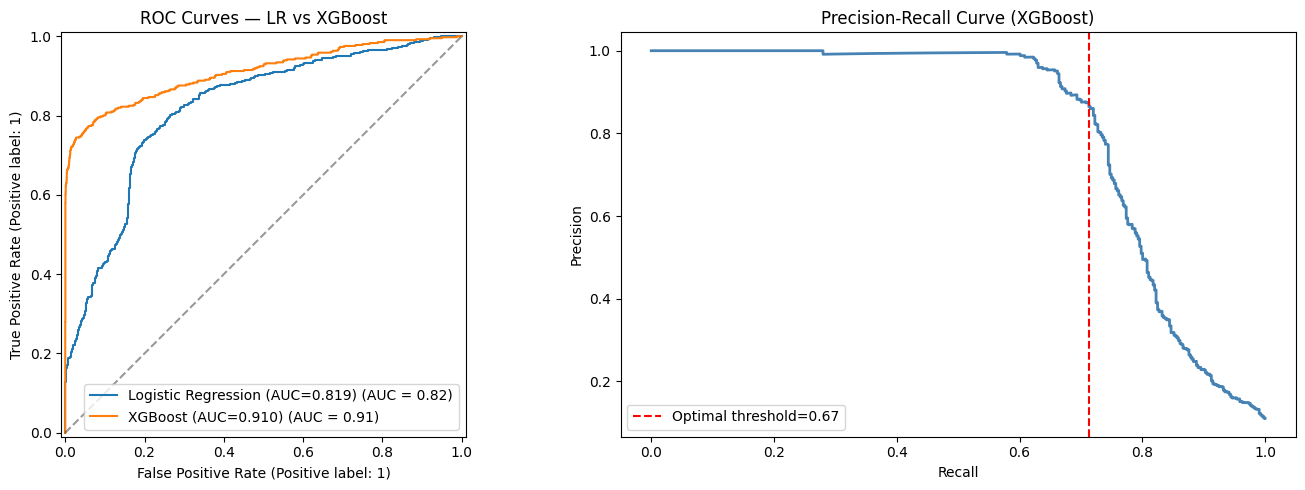

In [67]:
from sklearn.metrics import precision_recall_curve, f1_score

# Find threshold that maximises F1 for churned class
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx   = f1_scores.argmax()
best_thresh = thresholds[best_idx]

print(f"Optimal threshold   : {best_thresh:.3f}")
print(f"Precision at optimal: {precisions[best_idx]:.3f}")
print(f"Recall at optimal   : {recalls[best_idx]:.3f}")
print(f"F1 at optimal       : {f1_scores[best_idx]:.3f}")

xgb_preds_opt = (xgb_probs >= best_thresh).astype(int)
print("\nClassification Report (optimal threshold):")
print(classification_report(y_test, xgb_preds_opt,
                             target_names=['Not Churned','Churned']))

# Side-by-side ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, lr_probs,
    name=f'Logistic Regression (AUC={lr_auc:.3f})', ax=axes[0])
RocCurveDisplay.from_predictions(y_test, xgb_probs,
    name=f'XGBoost (AUC={xgb_auc:.3f})', ax=axes[0])
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_title("ROC Curves — LR vs XGBoost")

# Precision-Recall curve
axes[1].plot(recalls, precisions, color='steelblue', linewidth=2)
axes[1].axvline(recalls[best_idx], color='red', linestyle='--',
                label=f'Optimal threshold={best_thresh:.2f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title("Precision-Recall Curve (XGBoost)")
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150)
plt.show()

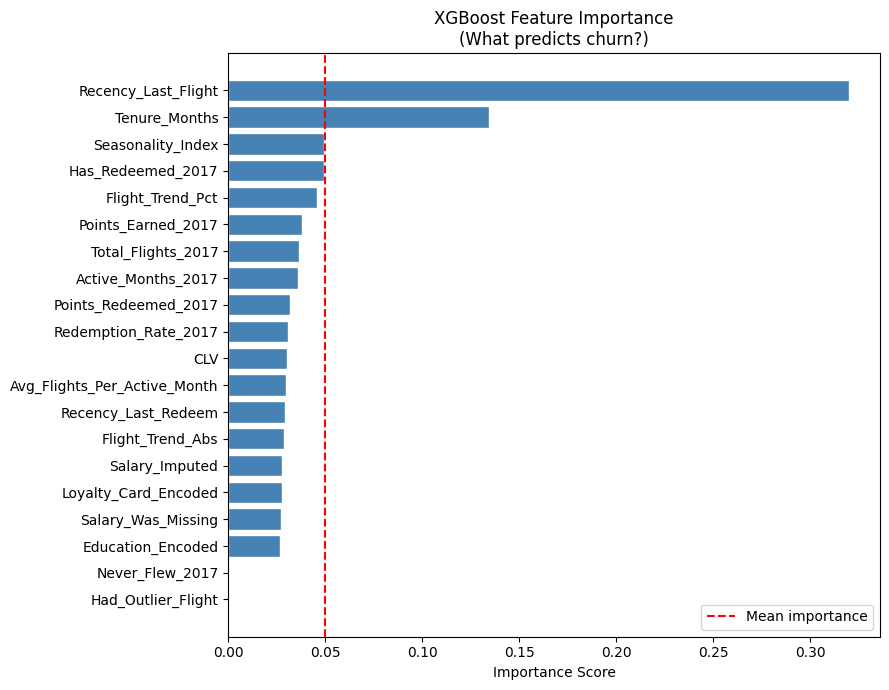


Top 5 churn predictors:
            Feature  Importance
   Flight_Trend_Pct    0.045823
  Has_Redeemed_2017    0.049388
  Seasonality_Index    0.049512
      Tenure_Months    0.134335
Recency_Last_Flight    0.320025

Bottom 5 (least predictive):
             Feature  Importance
  Had_Outlier_Flight    0.000000
     Never_Flew_2017    0.000000
   Education_Encoded    0.026499
  Salary_Was_Missing    0.027446
Loyalty_Card_Encoded    0.027550


In [68]:
importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(importance['Feature'], importance['Importance'],
         color='steelblue', edgecolor='white')
plt.axvline(importance['Importance'].mean(), color='red',
            linestyle='--', label='Mean importance')
plt.title("XGBoost Feature Importance\n(What predicts churn?)")
plt.xlabel("Importance Score")
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 churn predictors:")
print(importance.tail(5)[['Feature','Importance']].to_string(index=False))
print("\nBottom 5 (least predictive):")
print(importance.head(5)[['Feature','Importance']].to_string(index=False))

In [ ]:
# Generate churn probability for every customer in the feature matrix
all_probs = xgb.predict_proba(X)[:, 1]

feat['Churn_Probability'] = all_probs
feat['Churn_Risk_Tier']   = pd.cut(
    feat['Churn_Probability'],
    bins   = [0, 0.20, 0.45, 0.70, 1.0],
    labels = ['Low', 'Medium', 'High', 'Critical']
)

print("Churn risk tier distribution:")
print(feat['Churn_Risk_Tier'].value_counts().sort_index())
print(f"\nChurn probability stats:")
print(feat['Churn_Probability'].describe().round(3))

feat.to_csv('data/processed/feature_matrix_scored.csv', index=False)
print(f"\nSaved feature_matrix_scored.csv: {feat.shape}")

Churn risk tier distribution:
Churn_Risk_Tier
Low         10897
Medium       1985
High          502
Critical     1466
Name: count, dtype: int64

Churn probability stats:
count    14850.000
mean         0.200
std          0.275
min          0.000
25%          0.035
50%          0.087
75%          0.216
max          0.999
Name: Churn_Probability, dtype: float64

Saved feature_matrix_scored.csv: (14850, 32)


## **SEGMENTATION**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

feat = pd.read_csv('data/processed/feature_matrix_scored.csv')

# Cluster on behavior only — demographics come AFTER to describe segments
cluster_features = [
    'Recency_Last_Flight',
    'Active_Months_2017',
    'Avg_Flights_Per_Active_Month',
    'Redemption_Rate_2017',
    'Flight_Trend_Pct',
    'Seasonality_Index',
    'Points_Earned_2017',
    'Tenure_Months'          # included — new vs veteran behavior differs structurally
]

X_clust = feat[cluster_features].copy()

scaler_c = StandardScaler()
X_scaled = scaler_c.fit_transform(X_clust)

print(f"Clustering matrix: {X_scaled.shape}")
print(f"Features: {cluster_features}")

Clustering matrix: (14850, 8)
Features: ['Recency_Last_Flight', 'Active_Months_2017', 'Avg_Flights_Per_Active_Month', 'Redemption_Rate_2017', 'Flight_Trend_Pct', 'Seasonality_Index', 'Points_Earned_2017', 'Tenure_Months']


PCA components retained: 5
Variance explained per component: [0.469 0.222 0.122 0.073 0.064]
Cumulative variance explained: [0.469 0.691 0.813 0.886 0.949]


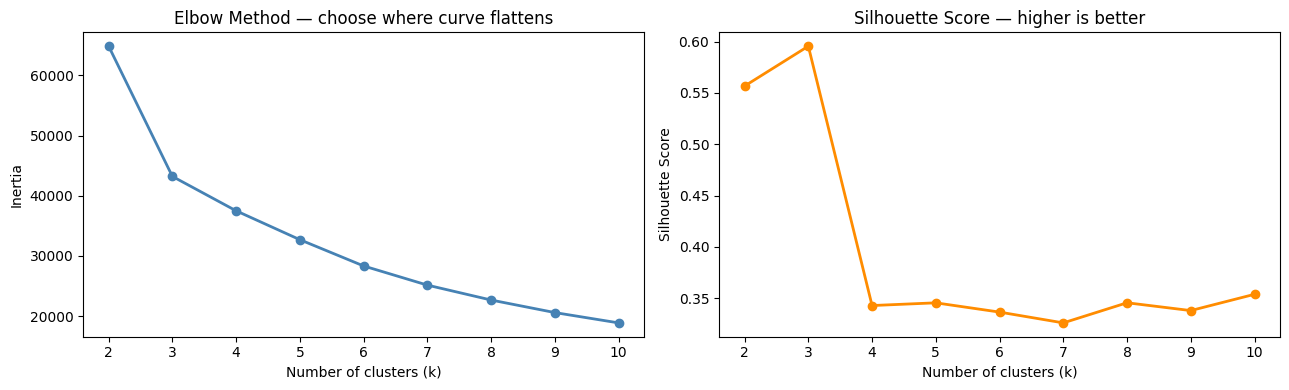

k=2  silhouette=0.5567
k=3  silhouette=0.5956
k=4  silhouette=0.3429
k=5  silhouette=0.3456
k=6  silhouette=0.3365
k=7  silhouette=0.3260
k=8  silhouette=0.3456
k=9  silhouette=0.3380
k=10  silhouette=0.3539


In [71]:
# PCA — retain 90% of variance
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA components retained: {X_pca.shape[1]}")
print(f"Variance explained per component: {pca.explained_variance_ratio_.round(3)}")
print(f"Cumulative variance explained: {pca.explained_variance_ratio_.cumsum().round(3)}")

# Elbow method + silhouette scores
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels, sample_size=3000))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title("Elbow Method — choose where curve flattens")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(K_range, silhouettes, marker='o', color='darkorange', linewidth=2)
axes[1].set_title("Silhouette Score — higher is better")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig('kmeans_selection.png', dpi=150)
plt.show()

for k, s in zip(K_range, silhouettes):
    print(f"k={k}  silhouette={s:.4f}")

In [72]:
km3 = KMeans(n_clusters=3, random_state=42, n_init=20)
feat['Segment_k3'] = km3.fit_predict(X_pca)

profile_cols_base = ['Recency_Last_Flight','Active_Months_2017',
                     'Avg_Flights_Per_Active_Month','Redemption_Rate_2017',
                     'Flight_Trend_Pct','Tenure_Months',
                     'CLV','Churn_Probability','Churned']

k3_profile = feat.groupby('Segment_k3')[profile_cols_base].mean().round(3)
k3_profile.insert(0, 'Size', feat['Segment_k3'].value_counts().sort_index())
print("k=3 Profile (baseline structure):")
print(k3_profile.to_string())

k=3 Profile (baseline structure):
             Size  Recency_Last_Flight  Active_Months_2017  Avg_Flights_Per_Active_Month  Redemption_Rate_2017  Flight_Trend_Pct  Tenure_Months       CLV  Churn_Probability  Churned
Segment_k3                                                                                                                                                                           
0           10759                0.744               7.143                         2.748                 0.018             0.270         47.740  7931.611              0.127    0.052
1            2422               11.975               0.011                         0.008                 0.000            -0.002         12.505  8126.476              0.477    0.290
2            1669                1.505               2.714                         2.664                 0.025             5.560         18.150  7850.939              0.268    0.228


In [73]:
OPTIMAL_K = 5
km5 = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
feat['Segment_ID'] = km5.fit_predict(X_pca)

profile_cols_full = [
    'Recency_Last_Flight', 'Active_Months_2017',
    'Avg_Flights_Per_Active_Month', 'Redemption_Rate_2017',
    'Flight_Trend_Pct', 'Seasonality_Index', 'Points_Earned_2017',
    'Tenure_Months', 'CLV', 'Salary_Imputed',
    'Loyalty_Card_Encoded', 'Churn_Probability', 'Churned'
]

k5_profile = feat.groupby('Segment_ID')[profile_cols_full].mean().round(3)
k5_profile.insert(0, 'Size', feat['Segment_ID'].value_counts().sort_index())
k5_profile.insert(1, 'Pct',
    (feat['Segment_ID'].value_counts(normalize=True).sort_index()*100).round(1))
k5_profile.insert(2, 'Churn_Rate_Pct',
    (feat.groupby('Segment_ID')['Churned'].mean()*100).round(1))

print("\nk=5 Full Profile:")
print(k5_profile.to_string())


k=5 Full Profile:
            Size   Pct  Churn_Rate_Pct  Recency_Last_Flight  Active_Months_2017  Avg_Flights_Per_Active_Month  Redemption_Rate_2017  Flight_Trend_Pct  Seasonality_Index  Points_Earned_2017  Tenure_Months       CLV  Salary_Imputed  Loyalty_Card_Encoded  Churn_Probability  Churned
Segment_ID                                                                                                                                                                                                                                                                             
0           6241  42.0             2.7                0.403               8.072                         2.860                 0.014             0.239              1.552           34994.865         53.732  8017.694       78946.782                 1.757              0.091    0.027
1           2418  16.3            29.0               11.996               0.003                         0.003                 0.000          

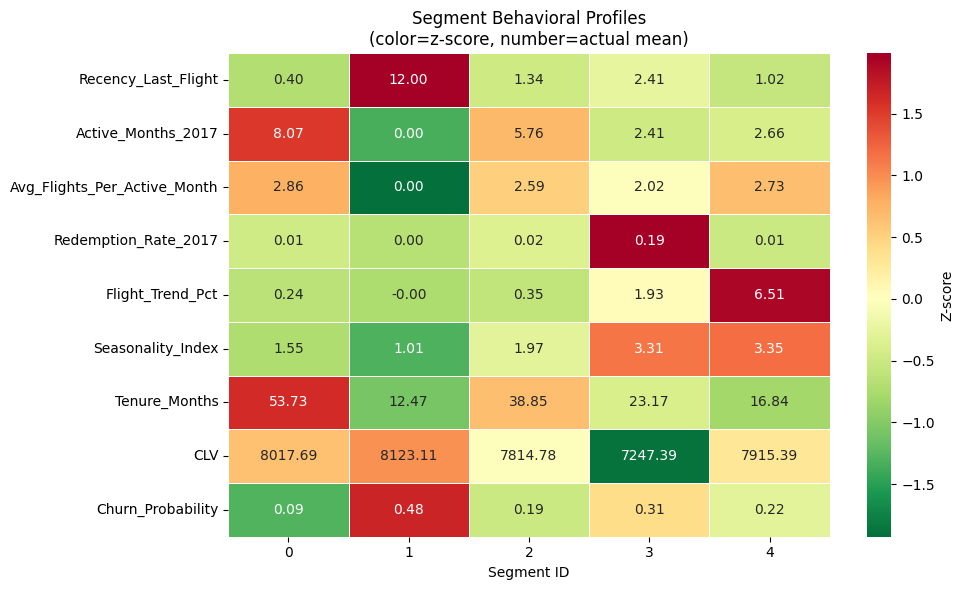

In [74]:
# Standardized heatmap so all features are on same scale
from scipy.stats import zscore

plot_features = ['Recency_Last_Flight','Active_Months_2017',
                 'Avg_Flights_Per_Active_Month','Redemption_Rate_2017',
                 'Flight_Trend_Pct','Seasonality_Index',
                 'Tenure_Months','CLV','Churn_Probability']

heatmap_data = feat.groupby('Segment_ID')[plot_features].mean()
heatmap_norm = heatmap_data.apply(zscore, axis=0).T  # z-score across segments

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_norm, annot=heatmap_data.T.round(2),
            fmt='.2f', cmap='RdYlGn_r', center=0,
            linewidths=0.5, cbar_kws={'label':'Z-score'})
plt.title("Segment Behavioral Profiles\n(color=z-score, number=actual mean)")
plt.xlabel("Segment ID")
plt.tight_layout()
plt.savefig('segment_heatmap.png', dpi=150)
plt.show()

In [75]:
print("CLV range across segments:")
print(k5_profile[['CLV']].to_string())
print(f"\nCLV spread (max-min): {k5_profile['CLV'].max() - k5_profile['CLV'].min():.0f}")
print(f"As % of mean CLV    : {(k5_profile['CLV'].max()-k5_profile['CLV'].min())/k5_profile['CLV'].mean()*100:.1f}%")

CLV range across segments:
                 CLV
Segment_ID          
0           8017.694
1           8123.108
2           7814.777
3           7247.389
4           7915.386

CLV spread (max-min): 876
As % of mean CLV    : 11.2%


In [ ]:
segment_names = {
    0: 'Loyal Regulars',
    1: 'Silent Enrollees',
    2: 'Occasional Travelers',
    3: 'Reward Maximizers',
    4: 'Rising Seasonal Flyers'
}
feat['Segment_Name'] = feat['Segment_ID'].map(segment_names)

summary = feat.groupby('Segment_Name').agg(
    Size              = ('Churned',              'count'),
    Churn_Rate_Pct    = ('Churned',              lambda x: round(x.mean()*100,1)),
    Avg_Churn_Prob    = ('Churn_Probability',     lambda x: round(x.mean(),3)),
    Avg_Flights       = ('Total_Flights_2017',    lambda x: round(x.mean(),1)),
    Avg_Recency       = ('Recency_Last_Flight',   lambda x: round(x.mean(),1)),
    Avg_Redemption    = ('Redemption_Rate_2017',  lambda x: round(x.mean(),3)),
    Avg_Tenure_Months = ('Tenure_Months',         lambda x: round(x.mean(),1)),
    Avg_CLV           = ('CLV',                   lambda x: round(x.mean(),0))
).sort_values('Churn_Rate_Pct', ascending=False)

print(summary.to_string())
feat.to_csv('dashboard/customers_final.csv', index=False)
print(f"\nSaved customers_final.csv: {feat.shape}")

                        Size  Churn_Rate_Pct  Avg_Churn_Prob  Avg_Flights  Avg_Recency  Avg_Redemption  Avg_Tenure_Months  Avg_CLV
Segment_Name                                                                                                                      
Silent Enrollees        2418            29.0           0.476          0.0         12.0           0.000               12.5   8123.0
Reward Maximizers        133            24.8           0.311          4.8          2.4           0.190               23.2   7247.0
Rising Seasonal Flyers  1350            18.9           0.221          7.3          1.0           0.012               16.8   7915.0
Occasional Travelers    4708            10.3           0.194         14.8          1.3           0.023               38.8   7815.0
Loyal Regulars          6241             2.7           0.091         22.9          0.4           0.014               53.7   8018.0

Saved customers_final.csv: (14850, 35)


In [77]:
# Assign retention priority based on churn risk × segment value
priority_map = {
    'Silent Enrollees'      : 'Urgent — Onboarding failure',
    'Reward Maximizers'     : 'Urgent — High engagement, at risk',
    'Rising Seasonal Flyers': 'High — Convert before next off-season',
    'Occasional Travelers'  : 'Medium — Frequency building',
    'Loyal Regulars'        : 'Maintain — Unlock redemption behavior'
}
feat['Retention_Priority'] = feat['Segment_Name'].map(priority_map)

print("Customers per retention priority:")
print(feat['Retention_Priority'].value_counts())

Customers per retention priority:
Retention_Priority
Maintain — Unlock redemption behavior    6241
Medium — Frequency building              4708
Urgent — Onboarding failure              2418
High — Convert before next off-season    1350
Urgent — High engagement, at risk         133
Name: count, dtype: int64


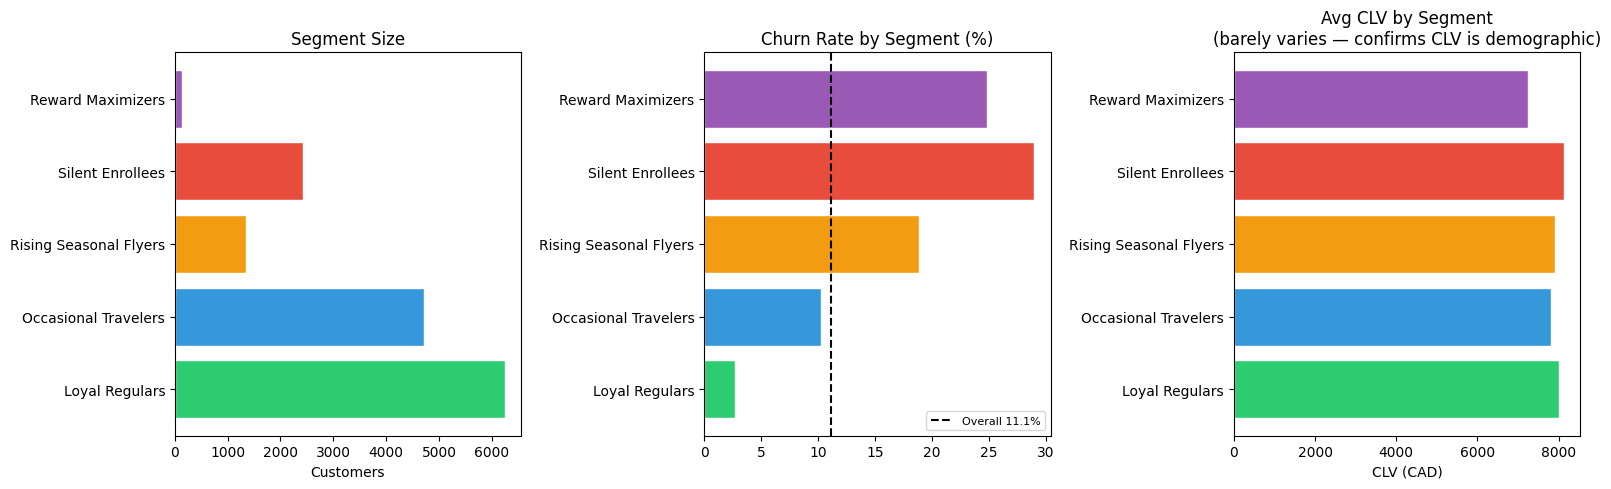

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

seg_order = ['Loyal Regulars','Occasional Travelers','Rising Seasonal Flyers',
             'Silent Enrollees','Reward Maximizers']
colors    = ['#2ecc71','#3498db','#f39c12','#e74c3c','#9b59b6']

# Chart 1: Segment size
sizes = [feat[feat['Segment_Name']==s].shape[0] for s in seg_order]
axes[0].barh(seg_order, sizes, color=colors, edgecolor='white')
axes[0].set_title("Segment Size")
axes[0].set_xlabel("Customers")

# Chart 2: Churn rate per segment
churn_rates = [feat[feat['Segment_Name']==s]['Churned'].mean()*100 for s in seg_order]
axes[1].barh(seg_order, churn_rates, color=colors, edgecolor='white')
axes[1].axvline(11.1, color='black', linestyle='--', label='Overall 11.1%')
axes[1].set_title("Churn Rate by Segment (%)")
axes[1].legend(fontsize=8)

# Chart 3: Avg CLV per segment (proving CLV doesn't differentiate)
clvs = [feat[feat['Segment_Name']==s]['CLV'].mean() for s in seg_order]
axes[2].barh(seg_order, clvs, color=colors, edgecolor='white')
axes[2].set_title("Avg CLV by Segment\n(barely varies — confirms CLV is demographic)")
axes[2].set_xlabel("CLV (CAD)")

plt.tight_layout()
plt.savefig('segment_overview.png', dpi=150)
plt.show()